# Análisis descriptivo del shock CERA

Este notebook explora el shock exógeno de depósitos vía el Régimen de Regularización de Activos (Ley 27.743, "blanqueo 2024") antes de cualquier regresión. El objetivo es (a) verificar que la magnitud y la forma del shock son las que esperamos, (b) ver cómo se distribuyó entre entidades, y (c) identificar potenciales problemas de identificación para los pasos de análisis subsiguientes.

Secciones:

1. **Datos y convenciones** — carga de panel, tipo de cambio, definición de cuentas CERA.
2. **Magnitud agregada del shock** — cuánto entró al sistema, composición por moneda y residencia, tamaño relativo al stock preexistente de depósitos USD.
3. **Distribución entre entidades** — qué bancos recibieron el flujo, concentración del shock, y relación con el tamaño preexistente del banco en USD.

Notas metodológicas referenciadas: `docs/notas/cera_regimen.md` (régimen CERA), `docs/notas/metodologia_paneles.md §3.6.bis` (convención de signos del balance).

# Datos y convenciones

Tres advertencias importantes que se aplican a todas las queries que siguen:

- Los saldos del panel de balance respetan **convención contable BCRA**. Los pasivos (como CERA, que son depósitos) tienen signo **negativo**. Tomamos `abs(saldo)` cuando queremos magnitud económica.
- Los saldos en cuentas en moneda extranjera están expresados en **pesos convertidos al tipo de cambio contable** (aproximadamente el A-3500 de fin de mes). Para leer en USD hay que dividir por el TC de la fecha.
- Las cuatro cuentas CERA son `311793` (pesos residentes país), `312183` (pesos residentes exterior), `315794` (USD residentes país, **dominante**) y `316147` (USD residentes exterior).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "utils"))
from paths import PANELES, DIMENSIONES, EXTERNAL, RAW, REPO

import json
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

pd.options.display.float_format = "{:,.2f}".format
plt.rcParams.update({"figure.figsize": (10, 4.5), "figure.dpi": 100})

PANEL_BAL = PANELES / "panel_balance_mensual_proforma.parquet"  # pro-forma por default: consolida Macro+BMA y Galicia+HSBC
DIM_ENT = DIMENSIONES / "dim_entidades.parquet"
CW_CUENTA = EXTERNAL / "crosswalks/cuenta_categoria.csv"
FX_JSON = RAW / "bcra_api/005_tc_mayorista_a3500.json"

CERA_CUENTAS = ("311793", "312183", "315794", "316147")
CERA_CUENTAS_USD = ("315794", "316147")
CERA_CUENTAS_ARS = ("311793", "312183")

## Tipo de cambio A-3500 a fin de mes

Lo armamos una sola vez al inicio para usarlo en todas las conversiones a USD.

In [2]:
with open(FX_JSON) as f:
    fx_raw = json.load(f)

fx = pd.DataFrame(fx_raw["results"][0]["detalle"])
fx["fecha"] = pd.to_datetime(fx["fecha"])
fx["yyyymm"] = fx["fecha"].dt.strftime("%Y%m").astype(int)
fx_eom = (fx.sort_values("fecha")
            .groupby("yyyymm", as_index=False)
            .tail(1)
            .reset_index(drop=True)
            [["yyyymm", "valor"]]
            .rename(columns={"valor": "tc_a3500"}))

print(f"TC A-3500 disponible: {fx_eom.yyyymm.min()} - {fx_eom.yyyymm.max()}, {len(fx_eom)} meses")
fx_eom.tail(6)

TC A-3500 disponible: 201501 - 202604, 136 meses


,yyyymm,tc_a3500
130,202511,"1,450.75"
131,202512,"1,459.42"
132,202601,"1,447.67"
133,202602,"1,408.97"
134,202603,"1,382.76"
135,202604,"1,387.70"


## IPC Nacional INDEC para deflactar variables en pesos

Variables ARS (caps 131, 311, 132, etc.) se reportan en pesos nominales. Para hacer comparables stocks a lo largo de 2022-2026 (donde la inflación argentina superó el 100% interanual) hay que deflactar por IPC.

Convención de este notebook:
- **Variables en ME** (caps 11x, 12x, 13x, 31x, 32x): convertir a USD nominales usando A-3500 de fin de mes (no se deflactan por CPI US — es trivial al lado del shock).
- **Variables en ARS** (caps 131, 311, 132, etc.): convertir a **pesos constantes de jul-2024** (mes de implementación CERA, Com. A 8062), deflactando por IPC Nacional INDEC.

In [3]:
# IPC Nacional general (Codigo=0, Region=Nacional) desde CSV INDEC
ipc_raw = pd.read_csv(RAW / 'indec_ipc/serie_ipc_divisiones.csv', sep=';', encoding='latin-1')
ipc_nac = ipc_raw[(ipc_raw['Codigo']=='0') & (ipc_raw['Region']=='Nacional')].copy()
ipc_nac['Periodo'] = ipc_nac['Periodo'].astype(int)
ipc_nac['Indice_IPC'] = ipc_nac['Indice_IPC'].astype(str).str.replace(',', '.').astype(float)
ipc_nac = ipc_nac.sort_values('Periodo').reset_index(drop=True)

# Diccionario yyyymm -> índice IPC
ipc = ipc_nac.set_index('Periodo')['Indice_IPC']

# Base para deflactación: jul-2024 (implementación CERA)
IPC_BASE_YYYYMM = 202407
IPC_BASE = ipc[IPC_BASE_YYYYMM]
print(f"IPC base ({IPC_BASE_YYYYMM}): {IPC_BASE:.2f}")
print(f"Cobertura IPC: {ipc.index.min()}–{ipc.index.max()}, {len(ipc)} meses")

# Helper: deflactar saldo en pesos a pesos constantes de jul-2024
def deflactar_ars(saldo_pesos, yyyymm):
    return saldo_pesos / ipc.loc[yyyymm] * IPC_BASE


IPC base (202407): 6607.75
Cobertura IPC: 201612–202603, 112 meses


# Configuración de ventanas de análisis

Sigue la decisión documentada en §4 de [`docs/notas/sintesis_para_modelo.md`](../../docs/notas/sintesis_para_modelo.md). Las celdas posteriores que dependen de un horizonte usan estas tres referencias:

- `T0 = 202406` (jun-2024) — pre-shock, base de toda comparación.
- `T1_CORTO = 202503` (mar-2025) — último mes pre-salida del cepo (14-abr-2025). Ventana de identificación: la asignación dentro del balance se puede leer mayormente como respuesta del banco al fondeo CERA bajo restricciones binding (encaje 25%, PGNME, menú 2.1).
- `T1_LARGO = 202601` (ene-2026) — terminal disponible. Mezcla la respuesta inicial al shock con la reasignación bajo régimen Milei (salida cepo, apreciación real, disinflación, baja de tasas en pesos). Útil como descriptivo de persistencia, no como evidencia causal.

In [4]:
T0 = 202406
T1_CORTO = 202503
T1_LARGO = 202601

VENTANAS = {
    "corta (jun-24 -> mar-25, pre-cepo)":  (T0, T1_CORTO),
    "larga (jun-24 -> ene-26, post-cepo)": (T0, T1_LARGO),
}

# Diccionario TC fin de mes para conversiones consistentes
tc = fx_eom.set_index("yyyymm")["tc_a3500"]
for nombre, (t0, t1) in VENTANAS.items():
    meses = (t1//100 - t0//100)*12 + (t1%100 - t0%100)
    print(f"{nombre:55s} TC[{t0}]={tc[t0]:>10,.2f}  TC[{t1}]={tc[t1]:>10,.2f}  {meses:>2d} meses")

corta (jun-24 -> mar-25, pre-cepo)                      TC[202406]=    911.75  TC[202503]=  1,073.88   9 meses
larga (jun-24 -> ene-26, post-cepo)                     TC[202406]=    911.75  TC[202601]=  1,447.67  19 meses


## Universo del paper: bancos comerciales (AA100)

Excluimos del universo de análisis a las **Compañías Financieras** (AA200 en la clasificación BCRA): captive finance de marcas automotrices (VOLKS, FCA, GPAT, DAIMLER, ROMBO, PSA, TOYOTA, J DEERE) + ARGENCF. No toman depósitos del público en ME y no participan del régimen de Aplicación de Recursos en ME — fuera del scope del lending channel.

También se excluyen las cajas de crédito cooperativas (45xxx) y la única entidad bajo régimen 65xxx (CRCF), por la misma razón.

Universo retenido: **`AA100 = BANCOS`** (públicos AA110 + privados AA120). Creamos una vista DuckDB `panel_bancos` con el panel filtrado y la usamos en todas las queries posteriores.

Caso límite: **Cetelem (00331)** y **RCI (00339)** son captive consumer finance pero tienen forma jurídica de banco (códigos 00xxx) y por eso pertenecen formalmente a AA100. Operativamente no tienen actividad ME, así que se filtrarán naturalmente cuando se requiera `activos_ME > 0` en pasos posteriores. Acá los dejamos en el universo.

In [5]:
DIM_GRUPOS = DIMENSIONES / "dim_grupos.parquet"

bancos_df = duckdb.sql(f"""
    select distinct codigo_entidad
    from '{DIM_GRUPOS}'
    where codigo_grupo = 'AA100'
""").df()

# CAVEAT: dim_grupos es snapshot del dump 202601 — no captura entidades dadas de baja
# durante el período. HSBC (00150) era banco AA100 activo jul-2024 a may-2025 y receptor
# importante de CERA (~USD 280-300M en el peak), pero en el snapshot ya está absorbido por
# Galicia y no figura en grupos. Lo agregamos manualmente.
# TODO refactor: 03_dim_grupos.ipynb debería construir dim_grupos histórico (entidad × mes × grupo)
# usando todos los dumps mensuales en lugar del último.
BANCOS_HISTORICOS_FALTANTES = ["00150"]  # HSBC / GGAL — bank, activo durante el shock

BANCOS_AA100 = tuple(sorted(set(bancos_df.codigo_entidad.tolist()) | set(BANCOS_HISTORICOS_FALTANTES)))
print(f"Universo retenido (AA100 + bancos históricos): {len(BANCOS_AA100)} entidades")
print(f"  - de los cuales {len(bancos_df)} en AA100 vigentes (snapshot 202601)")
print(f"  - + {len(BANCOS_HISTORICOS_FALTANTES)} bancos históricos absorbidos pre-snapshot: {BANCOS_HISTORICOS_FALTANTES}")

duckdb.sql(f"""
    create or replace view panel_bancos as
    select * from '{PANEL_BAL}'
    where codigo_entidad in {BANCOS_AA100}
""")

excluidas = duckdb.sql(f"""
    select e.codigo_entidad, e.sigla, e.nombre, e.estado,
           string_agg(g.codigo_grupo, ',' order by g.codigo_grupo) as grupos
    from '{DIM_ENT}' e
    left join '{DIM_GRUPOS}' g on e.codigo_entidad = g.codigo_entidad
    where (e.es_agrupamiento = FALSE or e.es_agrupamiento is null)
      and e.codigo_entidad not in {BANCOS_AA100}
      and exists (
        select 1 from '{PANEL_BAL}' p
        where p.codigo_entidad = e.codigo_entidad and p.yyyymm between 202401 and 202506
      )
    group by e.codigo_entidad, e.sigla, e.nombre, e.estado
    order by e.codigo_entidad
""").df()
print(f"\nEntidades activas en el período del shock (2024-2025) excluidas: {len(excluidas)}")
excluidas


# Vista de dim_entidades con siglas/nombres parchados para entidades absorbidas pre-snapshot
# (en el dump 202601, HSBC figura como "Banco GGAL S.A." sin sigla; le devolvemos la identidad histórica)
SIGLAS_OVERRIDE = {
    "00150": ("HSBC", "HSBC Bank Argentina S.A."),
}
overrides_sql = "values " + ", ".join([f"('{k}', '{s}', '{n}')" for k,(s,n) in SIGLAS_OVERRIDE.items()])
duckdb.sql(f"""
    create or replace view dim_entidades_patched as
    select
      e.codigo_entidad,
      coalesce(o.sigla_override, e.sigla) as sigla,
      coalesce(o.nombre_override, e.nombre) as nombre,
      e.estado,
      case when o.codigo_entidad is not null then TRUE else e.es_vigente end as es_vigente,
      e.es_agrupamiento
    from '{DIM_ENT}' e
    left join ({overrides_sql}) as o(codigo_entidad, sigla_override, nombre_override)
      on e.codigo_entidad = o.codigo_entidad
""")


Universo retenido (AA100 + bancos históricos): 61 entidades
  - de los cuales 60 en AA100 vigentes (snapshot 202601)
  - + 1 bancos históricos absorbidos pre-snapshot: ['00150']

Entidades activas en el período del shock (2024-2025) excluidas: 15


# Magnitud agregada del shock

## Evolución mensual del saldo CERA total

Serie de tiempo del saldo agregado de las cuatro cuentas CERA, sumado sobre todo el sistema. Se expresa en billones de pesos y en miles de millones de USD (convertido al A-3500 de fin de mes).

In [6]:
cera_mensual = duckdb.sql(f"""
    select yyyymm,
           abs(sum(saldo)) as saldo_ars,
           count(distinct codigo_entidad) filter (where saldo != 0) as bancos_con_saldo
    from panel_bancos
    where codigo_cuenta in {CERA_CUENTAS}
    group by yyyymm
    order by yyyymm
""").df()

cera_mensual = cera_mensual.merge(fx_eom, on="yyyymm", how="left")
cera_mensual["saldo_billones_ars"] = cera_mensual["saldo_ars"] / 1e12
cera_mensual["saldo_miles_millones_usd"] = cera_mensual["saldo_ars"] / cera_mensual["tc_a3500"] / 1e9
cera_mensual["fecha"] = pd.to_datetime(cera_mensual["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

# muestro las observaciones desde jun-2024 (un mes antes del inicio del régimen)
cera_mensual[cera_mensual.yyyymm >= 202406][["yyyymm", "bancos_con_saldo", "saldo_billones_ars", "saldo_miles_millones_usd"]]

,yyyymm,bancos_con_saldo,saldo_billones_ars,saldo_miles_millones_usd
0,202407,4,0.00,0.00
1,202408,26,0.54,0.57
2,202409,40,11.73,12.08
3,202410,42,12.17,12.28
4,202411,38,7.84,7.74
5,202412,37,6.02,5.83
6,202501,37,5.29,5.02
7,202502,37,4.78,4.49
8,202503,37,4.29,3.99
9,202504,37,4.19,3.57


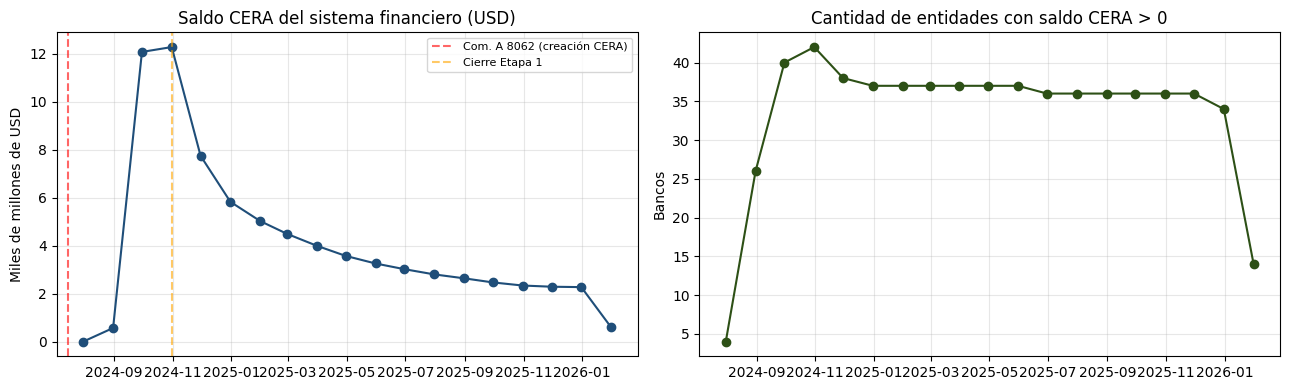

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
serie = cera_mensual[cera_mensual.yyyymm >= 202406]

ax1.plot(serie.fecha, serie.saldo_miles_millones_usd, marker="o", color="#1f4e79")
ax1.set_title("Saldo CERA del sistema financiero (USD)")
ax1.set_ylabel("Miles de millones de USD")
ax1.grid(alpha=0.3)
ax1.axvline(pd.Timestamp("2024-07-15"), ls="--", color="red", alpha=0.6, label="Com. A 8062 (creación CERA)")
ax1.axvline(pd.Timestamp("2024-10-31"), ls="--", color="orange", alpha=0.6, label="Cierre Etapa 1")
ax1.legend(loc="upper right", fontsize=8)

ax2.plot(serie.fecha, serie.bancos_con_saldo, marker="o", color="#2d5016")
ax2.set_title("Cantidad de entidades con saldo CERA > 0")
ax2.set_ylabel("Bancos")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Composición por cuenta

Las cuatro cuentas CERA corresponden a cuatro combinaciones `{moneda} × {residencia del titular}`. La hipótesis previa es que la cuenta `315794` (USD, residentes del país) concentra casi todo el flujo, porque el blanqueo apuntó principalmente a residentes argentinos con tenencias no declaradas en dólares.

In [8]:
cera_por_cuenta = duckdb.sql(f"""
    select yyyymm, codigo_cuenta,
           abs(sum(saldo)) / 1e12 as saldo_billones_ars
    from panel_bancos
    where codigo_cuenta in {CERA_CUENTAS}
    group by yyyymm, codigo_cuenta
    order by yyyymm, codigo_cuenta
""").df()

pivot = cera_por_cuenta.pivot(index="yyyymm", columns="codigo_cuenta", values="saldo_billones_ars").fillna(0)
pivot.columns = [f"{c} ({desc})" for c, desc in zip(pivot.columns, [
    "ARS residentes país", "ARS residentes exterior", "USD residentes país", "USD residentes exterior"
])]
pivot = pivot[pivot.index >= 202406]
pivot

,311793 (ARS residentes país),312183 (ARS residentes exterior),315794 (USD residentes país),316147 (USD residentes exterior)
yyyymm,,,,
202407,0.00,0.00,0.00,0.00
202408,0.02,0.00,0.52,0.00
202409,0.38,0.00,11.35,0.00
202410,0.41,0.00,11.76,0.00
202411,0.09,0.00,7.75,0.00
202412,0.05,0.00,5.97,0.00
202501,0.03,0.00,5.26,0.00
202502,0.02,0.00,4.76,0.00
202503,0.03,0.00,4.26,0.00


In [9]:
# Participación porcentual de cada cuenta sobre el total en el peak
peak = pivot.loc[pivot.sum(axis=1).idxmax()]
participaciones = (peak / peak.sum() * 100).round(2)
print(f"Mes peak: {pivot.sum(axis=1).idxmax()}")
print("Participación de cada cuenta en el saldo total del mes peak (%):")
participaciones

Mes peak: 202410
Participación de cada cuenta en el saldo total del mes peak (%):


311793 (ARS residentes país)        3.36
312183 (ARS residentes exterior)    0.00
315794 (USD residentes país)       96.64
316147 (USD residentes exterior)    0.00
Name: 202410, dtype: float64

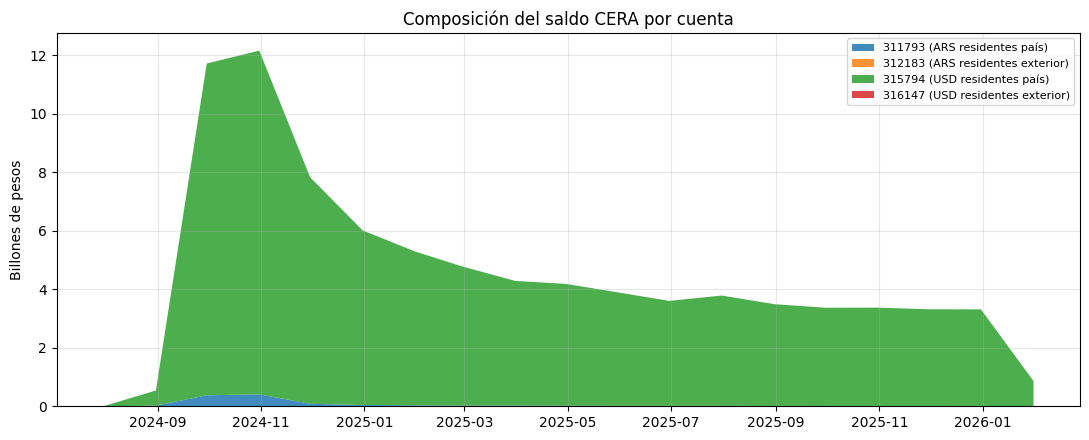

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
fechas = pd.to_datetime(pivot.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
ax.stackplot(fechas, pivot.T.values, labels=pivot.columns, alpha=0.85)
ax.set_title("Composición del saldo CERA por cuenta")
ax.set_ylabel("Billones de pesos")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tamaño relativo al stock preexistente de depósitos USD

Para dimensionar, comparamos el saldo CERA contra el total de depósitos en moneda extranjera del sector privado no financiero (capítulos 315 y 316, que incluyen todos los depósitos ME residentes país + exterior). El ratio muestra qué fracción de los depósitos USD corresponde específicamente a CERA en cada mes.

In [11]:
ratio_cera = duckdb.sql(f"""
    with cera as (
        select yyyymm, abs(sum(saldo)) as cera_ars
        from panel_bancos
        where codigo_cuenta in {CERA_CUENTAS_USD}
        group by yyyymm
    ),
    depositos_usd as (
        select yyyymm, abs(sum(saldo)) as depositos_usd_ars
        from panel_bancos
        where codigo_cuenta like '315%' or codigo_cuenta like '316%'
        group by yyyymm
    )
    select d.yyyymm,
           d.depositos_usd_ars / 1e12 as depositos_usd_billones,
           coalesce(c.cera_ars, 0) / 1e12 as cera_usd_billones,
           coalesce(c.cera_ars, 0) / d.depositos_usd_ars as ratio_cera_sobre_depositos_usd
    from depositos_usd d
    left join cera c using (yyyymm)
    where d.yyyymm >= 202401
    order by d.yyyymm
""").df()

ratio_cera

,yyyymm,depositos_usd_billones,cera_usd_billones,ratio_cera_sobre_depositos_usd
0,202401,15.51,0.00,0.00
1,202402,15.74,0.00,0.00
2,202403,16.41,0.00,0.00
3,202404,17.03,0.00,0.00
4,202405,17.67,0.00,0.00
5,202406,18.19,0.00,0.00
6,202407,19.68,0.00,0.00
7,202408,20.65,0.52,0.03
8,202409,32.73,11.35,0.35
9,202410,36.58,11.76,0.32


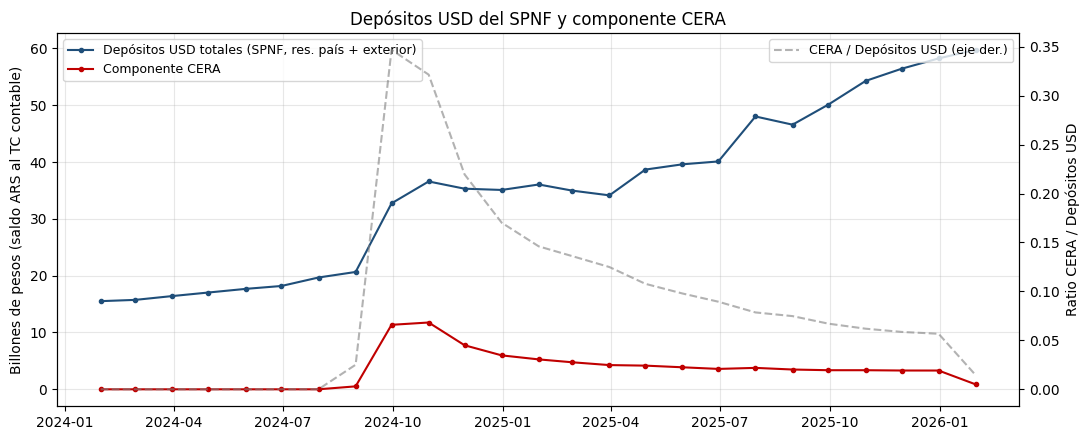

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
fechas = pd.to_datetime(ratio_cera.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

ax.plot(fechas, ratio_cera.depositos_usd_billones, label="Depósitos USD totales (SPNF, res. país + exterior)", color="#1f4e79", marker="o", ms=3)
ax.plot(fechas, ratio_cera.cera_usd_billones, label="Componente CERA", color="#c00000", marker="o", ms=3)
ax.set_title("Depósitos USD del SPNF y componente CERA")
ax.set_ylabel("Billones de pesos (saldo ARS al TC contable)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

ax2 = ax.twinx()
ax2.plot(fechas, ratio_cera.ratio_cera_sobre_depositos_usd, color="gray", ls="--", alpha=0.6, label="CERA / Depósitos USD (eje der.)")
ax2.set_ylabel("Ratio CERA / Depósitos USD")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## Persistencia: CERA se transforma en depósitos USD regulares

Hipótesis: el saldo específico de las cuatro cuentas CERA cae después del peak (oct-2024), pero los fondos no salen del sistema — se reclasifican dentro del mismo balance bancario a cuentas USD "normales" del capítulo 315 + 316 (cajas de ahorro ME, cuentas corrientes ME, plazos fijos ME).

Verificación: comparamos la caída del saldo CERA con la evolución del resto de depósitos USD (total 315+316 menos CERA).

In [13]:
persistencia = duckdb.sql(f"""
    with t as (
        select yyyymm,
               abs(sum(case when codigo_cuenta in {CERA_CUENTAS_USD} then saldo else 0 end)) as cera_usd,
               abs(sum(case when (codigo_cuenta like '315%' or codigo_cuenta like '316%')
                             and codigo_cuenta not in {CERA_CUENTAS} then saldo else 0 end)) as resto_usd,
               abs(sum(case when codigo_cuenta like '315%' or codigo_cuenta like '316%' then saldo else 0 end)) as total_usd
        from panel_bancos
        group by yyyymm
    )
    select * from t where yyyymm >= 202401 order by yyyymm
""").df()

persistencia = persistencia.merge(fx_eom, on="yyyymm", how="left")
for col in ["cera_usd", "resto_usd", "total_usd"]:
    persistencia[col.replace("_usd", "_miles_mill_usd")] = persistencia[col] / persistencia["tc_a3500"] / 1e9

persistencia[["yyyymm", "cera_miles_mill_usd", "resto_miles_mill_usd", "total_miles_mill_usd"]].round(2)

,yyyymm,cera_miles_mill_usd,resto_miles_mill_usd,total_miles_mill_usd
0,202401,0.00,18.78,18.78
1,202402,0.00,18.69,18.69
2,202403,0.00,19.14,19.14
3,202404,0.00,19.43,19.43
4,202405,0.00,19.74,19.74
5,202406,0.00,19.95,19.95
6,202407,0.00,21.09,21.10
7,202408,0.54,21.13,21.67
8,202409,11.69,22.02,33.71
9,202410,11.87,25.05,36.92


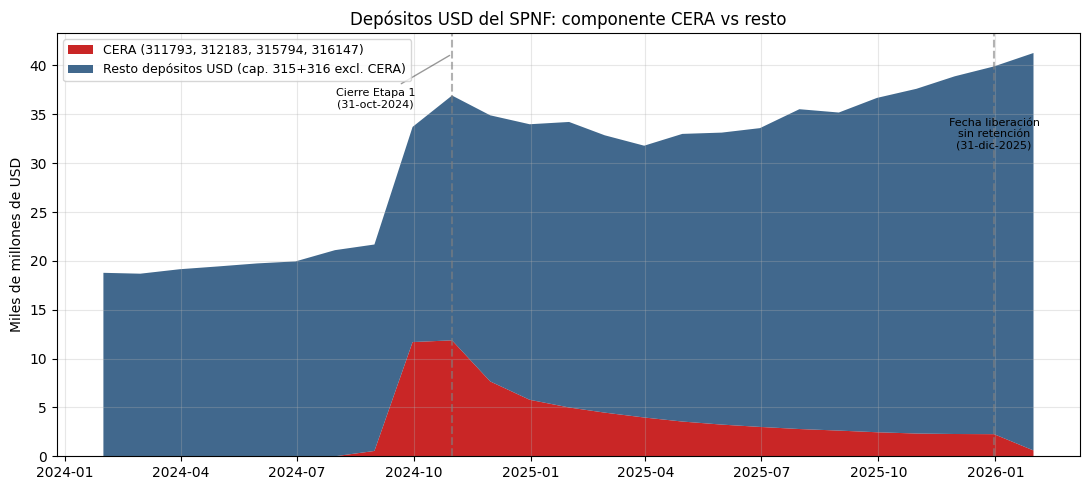

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
fechas = pd.to_datetime(persistencia.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

ax.stackplot(fechas,
             persistencia.cera_miles_mill_usd,
             persistencia.resto_miles_mill_usd,
             labels=["CERA (311793, 312183, 315794, 316147)", "Resto depósitos USD (cap. 315+316 excl. CERA)"],
             colors=["#c00000", "#1f4e79"], alpha=0.85)
ax.set_title("Depósitos USD del SPNF: componente CERA vs resto")
ax.set_ylabel("Miles de millones de USD")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
ax.axvline(pd.Timestamp("2024-10-31"), ls="--", color="gray", alpha=0.6)
ax.axvline(pd.Timestamp("2025-12-31"), ls="--", color="gray", alpha=0.6)
ax.annotate("Cierre Etapa 1\n(31-oct-2024)", (pd.Timestamp("2024-10-31"), ax.get_ylim()[1]*0.95),
            fontsize=8, ha="center", va="top", xytext=(pd.Timestamp("2024-09-01"), ax.get_ylim()[1]*0.87),
            arrowprops=dict(arrowstyle="-", alpha=0.4))
ax.annotate("Fecha liberación\nsin retención\n(31-dic-2025)", (pd.Timestamp("2025-12-31"), ax.get_ylim()[1]*0.80),
            fontsize=8, ha="center", va="top")

plt.tight_layout()
plt.show()

Observación: mientras CERA baja desde el peak hacia cero entre oct-2024 y ene-2026, el **resto de depósitos USD** sigue creciendo. El **total de depósitos USD del sistema** pasó de USD ~20B pre-shock a USD ~41B en ene-2026 — se duplicó. La plata se quedó en el sistema, cambió de cuenta interna.

**Implicancia conceptual**: para los bancos, el shock relevante no es "CERA peak" sino **"aumento de depósitos USD por encima de la tendencia pre-shock"**. Esta diferencia es central para definir el tratamiento en las regresiones.

# Distribución entre entidades

## Ranking de entidades por saldo CERA peak

Primera pregunta para la identificación: ¿qué bancos captaron el shock? La concentración importa. Si tres bancos concentran el 80%+ del flujo, la variación cross-section es débil y la estrategia econométrica se complica.

In [15]:
ranking = duckdb.sql(f"""
    with por_mes as (
        select codigo_entidad, yyyymm, abs(sum(saldo)) as saldo_mes
        from panel_bancos
        where codigo_cuenta in {CERA_CUENTAS}
        group by codigo_entidad, yyyymm
    ),
    peaks as (
        select codigo_entidad, max(saldo_mes) as saldo_peak,
               arg_max(yyyymm, saldo_mes) as mes_peak
        from por_mes
        where saldo_mes > 0
        group by codigo_entidad
    )
    select p.codigo_entidad, e.nombre, e.sigla, p.mes_peak,
           p.saldo_peak / 1e9 as saldo_peak_miles_millones_ars
    from peaks p
    left join dim_entidades_patched e on p.codigo_entidad = e.codigo_entidad and e.es_vigente
    order by p.saldo_peak desc
""").df()

# convierto el saldo peak a USD usando el TC del mes del peak de cada banco
ranking = ranking.merge(fx_eom.rename(columns={"yyyymm": "mes_peak"}), on="mes_peak", how="left")
ranking["saldo_peak_miles_millones_usd"] = ranking["saldo_peak_miles_millones_ars"] * 1000 / ranking["tc_a3500"] / 1000

print(f"Entidades con saldo CERA alguna vez > 0: {len(ranking)}")
ranking.head(20)

Entidades con saldo CERA alguna vez > 0: 43


,codigo_entidad,nombre,sigla,mes_peak,saldo_peak_miles_millones_ars,tc_a3500,saldo_peak_miles_millones_usd
0,00007,Banco de Galicia y Buenos Aires S.A.,GALICIA,202410,"2,952.79",990.75,2.98
1,00072,Banco Santander Argentina S.A.,SANTAND,202410,"2,717.56",990.75,2.74
2,00017,Banco BBVA Argentina S.A.,BBVA.AR,202410,"1,456.48",990.75,1.47
3,00285,Banco Macro S.A.,MACRO,202409,"1,445.48",970.92,1.49
4,00011,Banco de la Nación Argentina,NACION,202410,861.78,990.75,0.87
5,00014,Banco de la Provincia de Buenos Aires,PRBSAS,202410,454.54,990.75,0.46
6,00015,Industrial and Commercial Bank of China (Argen...,INDUSTR,202409,429.13,970.92,0.44
7,00191,Banco Credicoop Cooperativo Limitado,CREDICO,202410,408.96,990.75,0.41
8,00034,Banco Patagonia S.A.,PATAGON,202409,293.61,970.92,0.30
9,00027,Banco Supervielle S.A.,SUPERVI,202410,290.89,990.75,0.29


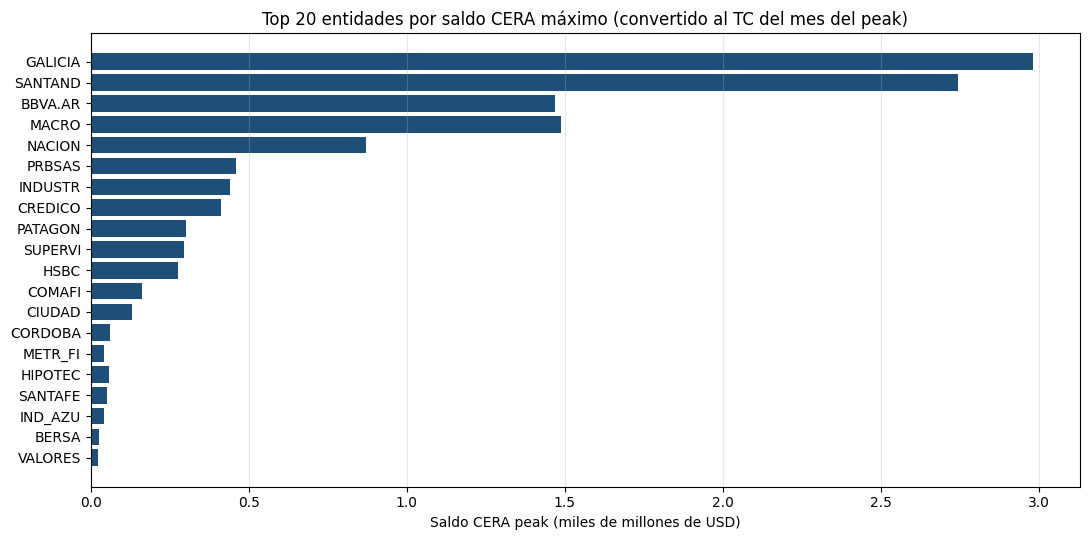

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
top = ranking.head(20).copy()
labels = top["sigla"].fillna(top["codigo_entidad"]).str[:12]
ax.barh(range(len(top)), top["saldo_peak_miles_millones_usd"], color="#1f4e79")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Saldo CERA peak (miles de millones de USD)")
ax.set_title("Top 20 entidades por saldo CERA máximo (convertido al TC del mes del peak)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Medidas de concentración

Calculamos el índice Herfindahl-Hirschman (HHI) y las participaciones acumuladas top-k a partir de los saldos CERA por banco en el mes del pico del sistema.

In [17]:
mes_peak_sistema = int(cera_mensual.loc[cera_mensual.saldo_ars.idxmax(), "yyyymm"])
print(f"Mes peak del sistema: {mes_peak_sistema}")

shares = duckdb.sql(f"""
    with saldos as (
        select codigo_entidad, abs(sum(saldo)) as saldo
        from panel_bancos
        where codigo_cuenta in {CERA_CUENTAS}
          and yyyymm = {mes_peak_sistema}
        group by codigo_entidad
        having saldo > 0
    )
    select codigo_entidad, saldo,
           saldo / (select sum(saldo) from saldos) as share
    from saldos
    order by saldo desc
""").df()

shares = shares.merge(
    duckdb.sql(f"select codigo_entidad, nombre, sigla from dim_entidades_patched where es_vigente").df(),
    on="codigo_entidad", how="left"
)

hhi = (shares["share"] ** 2).sum() * 10000  # HHI estándar sobre 10.000
share_top3 = shares.head(3)["share"].sum()
share_top5 = shares.head(5)["share"].sum()
share_top10 = shares.head(10)["share"].sum()

print(f"\nConcentración en el mes peak ({mes_peak_sistema}):")
print(f"  HHI:           {hhi:>8,.0f}   (interpretación: <1500 bajo, 1500-2500 moderado, >2500 alto)")
print(f"  Share top-3:   {share_top3:>8.1%}")
print(f"  Share top-5:   {share_top5:>8.1%}")
print(f"  Share top-10:  {share_top10:>8.1%}")
print(f"  Total bancos con saldo: {len(shares)}")

shares.head(10)[["codigo_entidad", "sigla", "nombre", "saldo", "share"]]

Mes peak del sistema: 202410

Concentración en el mes peak (202410):
  HHI:              1,466   (interpretación: <1500 bajo, 1500-2500 moderado, >2500 alto)
  Share top-3:      58.6%
  Share top-5:      77.0%
  Share top-10:     92.1%
  Total bancos con saldo: 42


,codigo_entidad,sigla,nombre,saldo,share
0,00007,GALICIA,Banco de Galicia y Buenos Aires S.A.,"2,952,786,967,000.00",0.24
1,00072,SANTAND,Banco Santander Argentina S.A.,"2,717,555,033,000.00",0.22
2,00017,BBVA.AR,Banco BBVA Argentina S.A.,"1,456,484,375,000.00",0.12
3,00285,MACRO,Banco Macro S.A.,"1,380,585,070,000.00",0.11
4,00011,NACION,Banco de la Nación Argentina,"861,781,610,000.00",0.07
5,00014,PRBSAS,Banco de la Provincia de Buenos Aires,"454,537,071,000.00",0.04
6,00015,INDUSTR,Industrial and Commercial Bank of China (Argen...,"414,109,037,000.00",0.03
7,00191,CREDICO,Banco Credicoop Cooperativo Limitado,"408,958,882,000.00",0.03
8,00027,SUPERVI,Banco Supervielle S.A.,"290,887,154,000.00",0.02
9,00150,HSBC,HSBC Bank Argentina S.A.,"272,930,299,000.00",0.02


## Relación entre tamaño preexistente y CERA recibida

La clave para la estrategia shift-share: ¿los bancos más grandes en depósitos USD antes del blanqueo son los mismos que recibieron más flujo? Un mapeo 1-a-1 significa que el shock es proporcional al tamaño, lo cual es consistente con que los depositantes eligieron bancos con los que ya tenían relación. Una dispersión alta en torno a la diagonal indicaría que el shock tiene un componente idiosincrático — potencialmente explotable.

In [18]:
# Share pre-shock: junio 2024, sobre depósitos USD totales (capítulos 315+316)
# Share CERA: sobre saldo CERA total en el mes peak
PRE_YYYYMM = 202406

pre_shares = duckdb.sql(f"""
    with dep_usd_pre as (
        select codigo_entidad, abs(sum(saldo)) as dep_usd_pre
        from panel_bancos
        where (codigo_cuenta like '315%' or codigo_cuenta like '316%')
          and yyyymm = {PRE_YYYYMM}
        group by codigo_entidad
        having dep_usd_pre > 0
    )
    select codigo_entidad, dep_usd_pre,
           dep_usd_pre / (select sum(dep_usd_pre) from dep_usd_pre) as share_pre
    from dep_usd_pre
""").df()

comparacion = shares[["codigo_entidad", "sigla", "saldo", "share"]].rename(columns={"share": "share_cera", "saldo": "saldo_cera"})
comparacion = comparacion.merge(pre_shares, on="codigo_entidad", how="outer").fillna(0)
comparacion = comparacion.sort_values("share_cera", ascending=False)
comparacion.head(15)

,codigo_entidad,sigla,saldo_cera,share_cera,dep_usd_pre,share_pre
0,00007,GALICIA,"2,952,786,967,000.00",0.24,"2,547,652,093,000.00",0.14
13,00072,SANTAND,"2,717,555,033,000.00",0.22,"2,546,930,714,000.00",0.14
5,00017,BBVA.AR,"1,456,484,375,000.00",0.12,"1,719,832,707,000.00",0.09
32,00285,MACRO,"1,380,585,070,000.00",0.11,"1,270,767,053,000.00",0.07
1,00011,NACION,"861,781,610,000.00",0.07,"2,765,443,152,000.00",0.15
2,00014,PRBSAS,"454,537,071,000.00",0.04,"1,299,161,883,000.00",0.07
3,00015,INDUSTR,"414,109,037,000.00",0.03,"698,784,139,000.00",0.04
23,00191,CREDICO,"408,958,882,000.00",0.03,"446,697,087,000.00",0.02
7,00027,SUPERVI,"290,887,154,000.00",0.02,"342,791,243,000.00",0.02
22,00150,HSBC,"272,930,299,000.00",0.02,"827,975,834,000.00",0.05


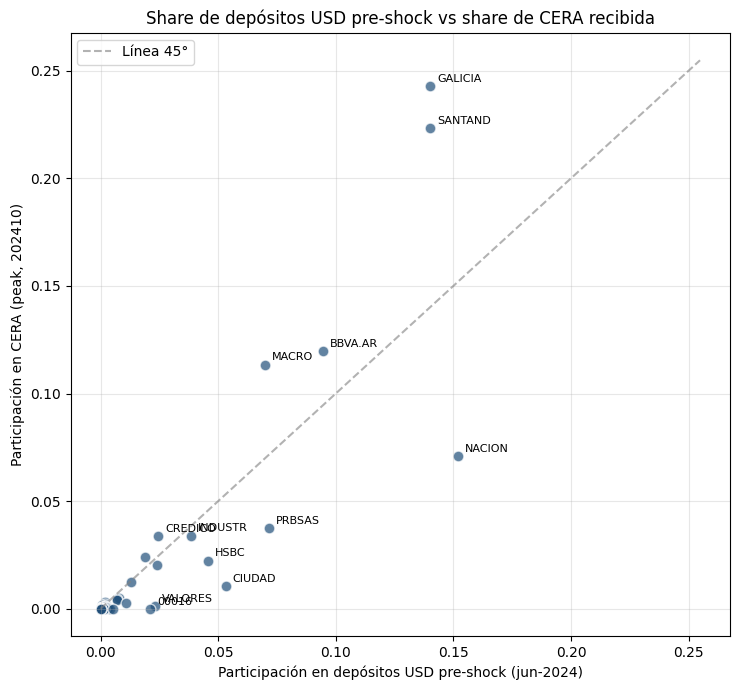

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 7))
x = comparacion["share_pre"]
y = comparacion["share_cera"]

ax.scatter(x, y, s=60, alpha=0.7, color="#1f4e79", edgecolor="white")
# Línea 45°
max_v = max(x.max(), y.max()) * 1.05
ax.plot([0, max_v], [0, max_v], ls="--", color="gray", alpha=0.6, label="Línea 45°")

# Etiquetas a los que están lejos de la diagonal o son muy grandes
for _, row in comparacion.iterrows():
    desviacion = abs(row.share_cera - row.share_pre)
    if row.share_cera > 0.03 or desviacion > 0.02:
        label = row.sigla if pd.notna(row.sigla) and row.sigla else row.codigo_entidad
        ax.annotate(str(label)[:8], (row.share_pre, row.share_cera), fontsize=8,
                    xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("Participación en depósitos USD pre-shock (jun-2024)")
ax.set_ylabel(f"Participación en CERA (peak, {mes_peak_sistema})")
ax.set_title("Share de depósitos USD pre-shock vs share de CERA recibida")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Métrica resumen: correlación de rangos + correlación lineal
from scipy.stats import spearmanr, pearsonr
mask = (comparacion.share_pre > 0) & (comparacion.share_cera > 0)
sub = comparacion[mask]

rho_spearman, _ = spearmanr(sub.share_pre, sub.share_cera)
rho_pearson, _ = pearsonr(sub.share_pre, sub.share_cera)

print(f"Correlación de rangos (Spearman): {rho_spearman:.3f}")
print(f"Correlación lineal (Pearson):     {rho_pearson:.3f}")
print(f"Bancos con share > 0 en ambos lados: {mask.sum()}")

Correlación de rangos (Spearman): 0.892
Correlación lineal (Pearson):     0.875
Bancos con share > 0 en ambos lados: 42


# Pre-tendencias de depósitos USD

Para que el shock CERA tenga interpretación exógena a nivel banco, los bancos que recibieron más flujo no deberían haber estado creciendo más rápido en depósitos USD antes del blanqueo. Acá chequeamos eso.

Medición: para cada banco, tasa de crecimiento de depósitos USD **en dólares reales** (convirtiendo saldos pesos al A-3500 de fin de mes) entre jul-2023 y jun-2024. Se compara contra la participación del banco en CERA peak.

In [21]:
# Saldos USD en dólares reales por banco en jul-2023 y jun-2024
q = f"""
with s as (
    select p.codigo_entidad, p.yyyymm,
           abs(sum(p.saldo)) as dep_ars
    from panel_bancos p
    where (p.codigo_cuenta like '315%' or p.codigo_cuenta like '316%')
      and p.yyyymm in (202307, 202406)
    group by p.codigo_entidad, p.yyyymm
)
select s.codigo_entidad, s.yyyymm, s.dep_ars / f.tc_a3500 as dep_usd
from s join fx_eom f using (yyyymm)
"""
sustento = duckdb.sql(q).df()

pre_pivot = sustento.pivot(index="codigo_entidad", columns="yyyymm", values="dep_usd")
pre_pivot.columns = ["dep_usd_jul2023", "dep_usd_jun2024"]
pre_pivot = pre_pivot.dropna()
pre_pivot = pre_pivot[pre_pivot["dep_usd_jul2023"] > 1e6]  # exige al menos USD 1M en el punto inicial
pre_pivot["crec_anual_pct"] = (pre_pivot["dep_usd_jun2024"] / pre_pivot["dep_usd_jul2023"] - 1) * 100

pre_pivot = pre_pivot.reset_index().merge(
    shares[["codigo_entidad", "sigla", "share"]].rename(columns={"share": "share_cera"}),
    on="codigo_entidad", how="left"
).dropna(subset=["share_cera"])

print(f"Bancos con serie pre-shock completa y CERA > 0: {len(pre_pivot)}")
pre_pivot.sort_values("share_cera", ascending=False).head(15)

Bancos con serie pre-shock completa y CERA > 0: 39


,codigo_entidad,dep_usd_jul2023,dep_usd_jun2024,crec_anual_pct,sigla,share_cera
0,00007,"1,944,390,202.70","2,794,244,138.20",43.71,GALICIA,0.24
13,00072,"2,328,924,742.08","2,793,452,935.56",19.95,SANTAND,0.22
5,00017,"1,473,532,832.03","1,886,298,554.43",28.01,BBVA.AR,0.12
30,00285,"1,209,662,692.53","1,393,766,989.85",15.22,MACRO,0.11
1,00011,"2,983,392,069.89","3,033,115,604.06",1.67,NACION,0.07
2,00014,"1,678,449,622.20","1,424,910,208.94",-15.11,PRBSAS,0.04
3,00015,"693,777,106.95","766,420,772.14",10.47,INDUSTR,0.03
23,00191,"508,906,004.80","489,933,739.51",-3.73,CREDICO,0.03
7,00027,"270,982,643.13","375,970,653.14",38.74,SUPERVI,0.02
22,00150,"820,033,384.19","908,117,174.66",10.74,HSBC,0.02


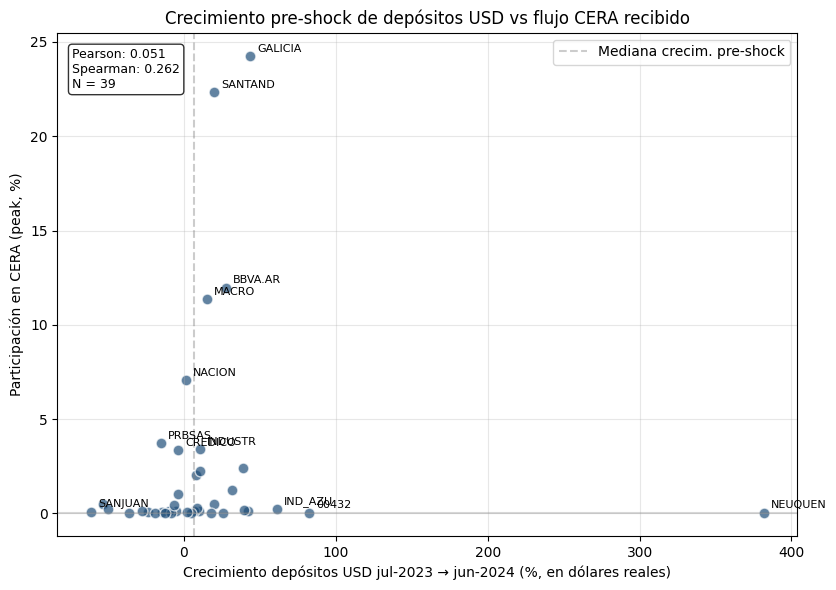

In [22]:
from scipy.stats import pearsonr, spearmanr

fig, ax = plt.subplots(figsize=(8.5, 6))
x = pre_pivot.crec_anual_pct
y = pre_pivot.share_cera * 100

ax.scatter(x, y, s=60, alpha=0.7, color="#1f4e79", edgecolor="white")
for _, row in pre_pivot.iterrows():
    if row.share_cera > 0.03 or abs(row.crec_anual_pct) > 60:
        ax.annotate(str(row.sigla)[:8] if pd.notna(row.sigla) else row.codigo_entidad,
                    (row.crec_anual_pct, row.share_cera * 100),
                    fontsize=8, xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("Crecimiento depósitos USD jul-2023 → jun-2024 (%, en dólares reales)")
ax.set_ylabel("Participación en CERA (peak, %)")
ax.set_title("Crecimiento pre-shock de depósitos USD vs flujo CERA recibido")
ax.grid(alpha=0.3)
ax.axhline(0, color="gray", alpha=0.3)
ax.axvline(pre_pivot.crec_anual_pct.median(), color="gray", ls="--", alpha=0.4, label="Mediana crecim. pre-shock")
ax.legend()

rho_p, _ = pearsonr(x, y)
rho_s, _ = spearmanr(x, y)
ax.text(0.02, 0.97, f"Pearson: {rho_p:.3f}\nSpearman: {rho_s:.3f}\nN = {len(pre_pivot)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

## Tendencia agregada por grupo de exposición

Agrupamos los bancos en cuartiles por su participación en CERA peak y graficamos la evolución mensual del stock de depósitos USD total de cada grupo en dólares reales, normalizado a 100 en jun-2024. Si los grupos tenían trayectorias paralelas pre-shock, la identificación gana respaldo.

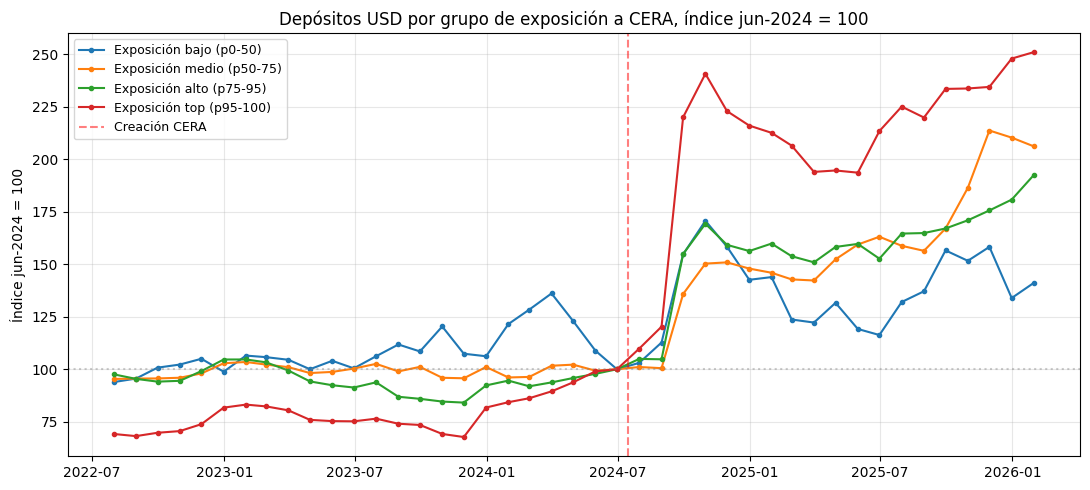

In [23]:
# Cuartiles por share_cera. Cargamos serie mensual completa de depósitos USD por banco.
q = f"""
select p.codigo_entidad, p.yyyymm, abs(sum(p.saldo)) as dep_ars
from panel_bancos p
where (p.codigo_cuenta like '315%' or p.codigo_cuenta like '316%')
  and p.yyyymm between 202207 and 202601
group by p.codigo_entidad, p.yyyymm
"""
serie_bancos = duckdb.sql(q).df()
serie_bancos = serie_bancos.merge(fx_eom, on="yyyymm", how="left")
serie_bancos["dep_usd"] = serie_bancos["dep_ars"] / serie_bancos["tc_a3500"]

# Asigno grupo de exposición
grupos_exposicion = pre_pivot[["codigo_entidad", "share_cera"]].copy()
grupos_exposicion["grupo_exposicion"] = pd.qcut(grupos_exposicion["share_cera"],
    q=[0, 0.5, 0.75, 0.95, 1.0],
    labels=["bajo (p0-50)", "medio (p50-75)", "alto (p75-95)", "top (p95-100)"])

serie_bancos = serie_bancos.merge(grupos_exposicion[["codigo_entidad", "grupo_exposicion"]],
                                   on="codigo_entidad", how="inner")

agreg = (serie_bancos.groupby(["grupo_exposicion", "yyyymm"], observed=True)["dep_usd"]
         .sum().reset_index())

# Normalizo a 100 en jun-2024 por grupo
base = agreg[agreg.yyyymm == 202406].set_index("grupo_exposicion")["dep_usd"]
agreg["indice"] = agreg.apply(lambda r: r.dep_usd / base[r.grupo_exposicion] * 100, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for grupo, df_g in agreg.groupby("grupo_exposicion", observed=True):
    df_g = df_g.sort_values("yyyymm")
    fechas = pd.to_datetime(df_g.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
    ax.plot(fechas, df_g["indice"], marker="o", ms=3, label=f"Exposición {grupo}")

ax.axvline(pd.Timestamp("2024-07-15"), ls="--", color="red", alpha=0.5, label="Creación CERA")
ax.axhline(100, color="gray", ls=":", alpha=0.4)
ax.set_title("Depósitos USD por grupo de exposición a CERA, índice jun-2024 = 100")
ax.set_ylabel("Índice jun-2024 = 100")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cuartiles alternativos: definición de exposición

La partición original usa `share_cera` (share del banco en CERA total del sistema) con cortes desbalanceados (p50/p75/p95) — el grupo top reúne pocos bancos grandes y el grupo bajo reúne muchos chicos sin flujo material.

Acá comparamos dos definiciones de exposición con cuartiles iguales (`q=4`) en ambas:

- **A — share-of-system**: `share_cera_b = saldo_CERA_b(peak) / Σ_b saldo_CERA_b(peak)`. "Qué fracción del flujo total capturó el banco".
- **B — intensidad**: `intensidad_b = saldo_CERA_b(peak) / dep_USD_b(jun-2024)`. "Qué tan grande fue el shock relativo al stock USD que el banco ya tenía". Más cercano al tipo de dosis usada en Khwaja-Mian / Greenstone-Mas-Nguyen.

In [24]:
# Construir las dos medidas de exposición a nivel banco
PEAK = 202410
PRE  = T0  # jun-2024

exposicion_alt = duckdb.sql(f"""
with cera_peak as (
    select codigo_entidad, abs(sum(saldo)) as cera_ars
    from panel_bancos
    where yyyymm = {PEAK} and codigo_cuenta in {CERA_CUENTAS}
    group by codigo_entidad
    having abs(sum(saldo)) > 0
),
dep_pre as (
    select codigo_entidad, abs(sum(saldo)) as dep_ars
    from panel_bancos
    where yyyymm = {PRE} and (codigo_cuenta like '315%' or codigo_cuenta like '316%')
    group by codigo_entidad
)
select cp.codigo_entidad, e.sigla, cp.cera_ars, dp.dep_ars
from cera_peak cp
left join dep_pre dp using (codigo_entidad)
left join dim_entidades_patched e on cp.codigo_entidad = e.codigo_entidad and e.es_vigente
""").df()

exposicion_alt["cera_usd"]    = exposicion_alt["cera_ars"] / tc[PEAK]
exposicion_alt["dep_usd_pre"] = exposicion_alt["dep_ars"] / tc[PRE]
exposicion_alt["share_cera"]  = exposicion_alt["cera_usd"] / exposicion_alt["cera_usd"].sum()
exposicion_alt["intensidad"]  = exposicion_alt["cera_usd"] / exposicion_alt["dep_usd_pre"].replace(0, np.nan)

exposicion_alt["cuartil_A_share"]      = pd.qcut(exposicion_alt["share_cera"], q=4, labels=["Q1","Q2","Q3","Q4"])
exposicion_alt["cuartil_B_intensidad"] = pd.qcut(exposicion_alt["intensidad"], q=4, labels=["Q1","Q2","Q3","Q4"])

print(f"Bancos con CERA peak > 0: {len(exposicion_alt)}")
exposicion_alt.sort_values("share_cera", ascending=False).head(10)

Bancos con CERA peak > 0: 42


,codigo_entidad,sigla,cera_ars,dep_ars,cera_usd,dep_usd_pre,share_cera,intensidad,cuartil_A_share,cuartil_B_intensidad
6,00007,GALICIA,"2,952,786,967,000.00","2,547,652,093,000.00","2,980,355,253.09","2,794,244,138.20",0.24,1.07,Q4,Q4
30,00072,SANTAND,"2,717,555,033,000.00","2,546,930,714,000.00","2,742,927,108.76","2,793,452,935.56",0.22,0.98,Q4,Q4
17,00017,BBVA.AR,"1,456,484,375,000.00","1,719,832,707,000.00","1,470,082,639.41","1,886,298,554.43",0.12,0.78,Q4,Q4
40,00285,MACRO,"1,380,585,070,000.00","1,270,767,053,000.00","1,393,474,711.08","1,393,766,989.85",0.11,1.00,Q4,Q4
0,00011,NACION,"861,781,610,000.00","2,765,443,152,000.00","869,827,514.51","3,033,115,604.06",0.07,0.29,Q4,Q2
27,00014,PRBSAS,"454,537,071,000.00","1,299,161,883,000.00","458,780,793.34","1,424,910,208.94",0.04,0.32,Q4,Q2
1,00015,INDUSTR,"414,109,037,000.00","698,784,139,000.00","417,975,308.60","766,420,772.14",0.03,0.55,Q4,Q3
22,00191,CREDICO,"408,958,882,000.00","446,697,087,000.00","412,777,069.90","489,933,739.51",0.03,0.84,Q4,Q4
28,00027,SUPERVI,"290,887,154,000.00","342,791,243,000.00","293,602,981.58","375,970,653.14",0.02,0.78,Q4,Q4
38,00150,HSBC,"272,930,299,000.00","827,975,834,000.00","275,478,474.89","908,117,174.66",0.02,0.30,Q4,Q2


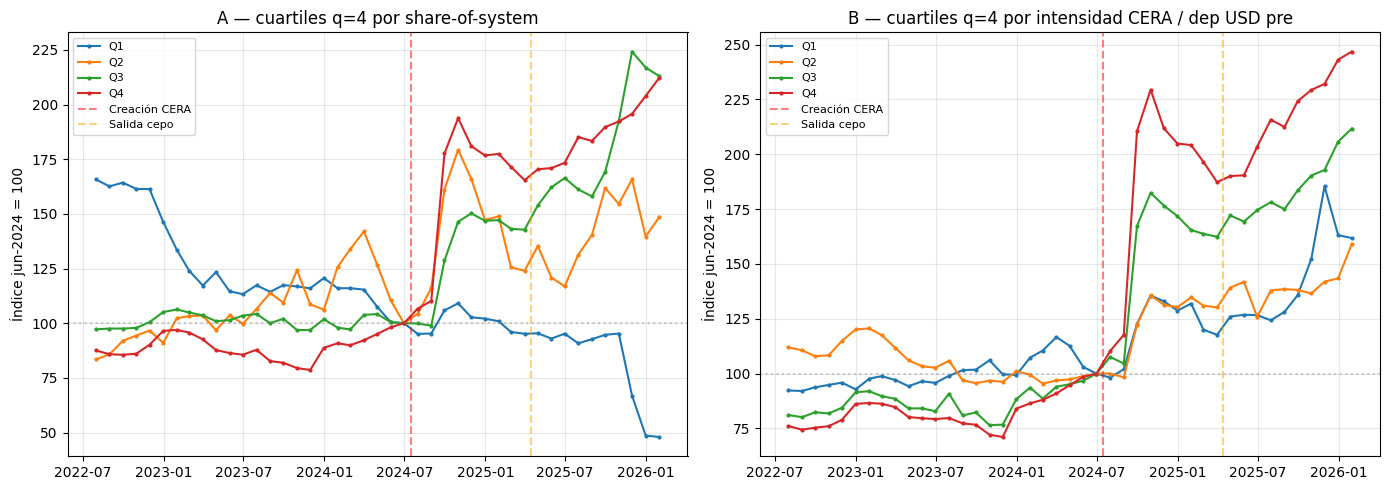

In [25]:
# Gráfico lado a lado: misma serie (dep USD del banco), dos particiones
def plot_grupo_alt(ax, columna_grupo, titulo):
    s = serie_bancos.merge(exposicion_alt[["codigo_entidad", columna_grupo]], on="codigo_entidad", how="inner")
    agreg = s.groupby([columna_grupo, "yyyymm"], observed=True)["dep_usd"].sum().reset_index()
    base = agreg[agreg.yyyymm == PRE].set_index(columna_grupo)["dep_usd"]
    agreg["indice"] = agreg.apply(lambda r: r.dep_usd / base[r[columna_grupo]] * 100, axis=1)
    for grupo, df_g in agreg.groupby(columna_grupo, observed=True):
        df_g = df_g.sort_values("yyyymm")
        fechas = pd.to_datetime(df_g.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
        ax.plot(fechas, df_g["indice"], marker="o", ms=2, label=str(grupo))
    ax.axvline(pd.Timestamp("2024-07-15"), ls="--", color="red",    alpha=0.5, label="Creación CERA")
    ax.axvline(pd.Timestamp("2025-04-14"), ls="--", color="orange", alpha=0.5, label="Salida cepo")
    ax.axhline(100, color="gray", ls=":", alpha=0.4)
    ax.set_title(titulo)
    ax.set_ylabel("Índice jun-2024 = 100")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))
plot_grupo_alt(axA, "cuartil_A_share",      "A — cuartiles q=4 por share-of-system")
plot_grupo_alt(axB, "cuartil_B_intensidad", "B — cuartiles q=4 por intensidad CERA / dep USD pre")
plt.tight_layout()
plt.show()

# Asignación del flujo dentro del balance

Una vez que un banco recibe depósitos ME adicionales, el Régimen de Aplicación de Recursos en Moneda Extranjera del BCRA limita las aplicaciones posibles a cuatro grandes canales del activo:

| Canal | Capítulo | Concepto |
|---|---|---|
| Efectivo y BCRA en ME | 115% | Encaje en ME + efectivo en ME (integración regulatoria) |
| Títulos públicos en ME | 125% | Bonos Tesoro USD + Letras BCRA ME |
| Crédito a SPNF en ME | 135% | Préstamos a empresas exportadoras y sectores generadores de divisas |
| Interbancario ME | 136% | Call, pases activos al BCRA en ME, operaciones entre entidades |

Acá medimos cómo se repartió el shock entre estos cuatro canales, primero a nivel sistema y después por banco. El período comparado es **pre-shock (jun-2024) vs post persistente (ene-2026)**, en dólares reales.

In [26]:
q = f"""
select p.codigo_entidad, p.yyyymm,
       abs(sum(case when p.codigo_cuenta like '115%' then p.saldo else 0 end)) as c115,
       abs(sum(case when p.codigo_cuenta like '125%' then p.saldo else 0 end)) as c125,
       abs(sum(case when p.codigo_cuenta like '135%' then p.saldo else 0 end)) as c135,
       abs(sum(case when p.codigo_cuenta like '136%' then p.saldo else 0 end)) as c136,
       abs(sum(case when p.codigo_cuenta like '315%' or p.codigo_cuenta like '316%' then p.saldo else 0 end)) as dep_usd_pasivo
from panel_bancos p
where p.yyyymm in ({T0}, {T1_CORTO})
group by p.codigo_entidad, p.yyyymm
"""
por_banco_canal = duckdb.sql(q).df()
por_banco_canal = por_banco_canal.merge(fx_eom, on="yyyymm", how="left")

# Convierto todo a USD (miles de millones) dividiendo por el TC de cada mes
for c in ["c115", "c125", "c135", "c136", "dep_usd_pasivo"]:
    por_banco_canal[c] = por_banco_canal[c] / por_banco_canal["tc_a3500"] / 1e9

por_banco_canal = por_banco_canal.drop(columns=["tc_a3500"])
por_banco_canal.head()

,codigo_entidad,yyyymm,c115,c125,c135,c136,dep_usd_pasivo
0,00339,202406,0.00,0.00,0.00,0.00,0.00
1,00432,202406,0.00,0.00,0.00,0.00,0.00
2,00435,202503,0.00,0.00,0.00,0.00,0.00
3,00016,202503,0.46,0.29,0.23,0.00,0.40
4,00029,202503,0.75,0.22,0.33,0.00,1.26


## Nivel sistema: ¿a qué canal fue el shock?

Sumo sobre todos los bancos y comparo jun-2024 vs ene-2026.

In [27]:
sistema = por_banco_canal.groupby("yyyymm")[["c115","c125","c135","c136","dep_usd_pasivo"]].sum()
sistema = sistema.T
sistema.columns = [f"jun_2024", "ene_2026"]
sistema["delta_usd_b"] = sistema["ene_2026"] - sistema["jun_2024"]
sistema["delta_pct"] = (sistema["ene_2026"] / sistema["jun_2024"] - 1) * 100
sistema = sistema.rename(index={
    "c115": "Efectivo y BCRA en ME (115)",
    "c125": "Títulos públicos en ME (125)",
    "c135": "Crédito a SPNF en ME (135)",
    "c136": "Interbancario ME (136)",
    "dep_usd_pasivo": "[Depósitos USD SPNF (315+316)]"
})
sistema.round(2)

,jun_2024,ene_2026,delta_usd_b,delta_pct
Efectivo y BCRA en ME (115),12.56,16.37,3.80,30.25
Títulos públicos en ME (125),7.00,4.04,-2.96,-42.32
Crédito a SPNF en ME (135),6.42,14.30,7.88,122.87
Interbancario ME (136),0.35,0.14,-0.21,-60.95
[Depósitos USD SPNF (315+316)],19.95,31.79,11.84,59.37


In [28]:
# Balance sheet identity check: ¿la suma de los 4 canales explica el aumento de depósitos USD?
delta_depositos = sistema.loc["[Depósitos USD SPNF (315+316)]", "delta_usd_b"]
delta_canales = sistema.loc[["Efectivo y BCRA en ME (115)", "Títulos públicos en ME (125)",
                              "Crédito a SPNF en ME (135)", "Interbancario ME (136)"], "delta_usd_b"].sum()
print(f"Δ Depósitos USD del SPNF (jun-2024 → ene-2026):     USD {delta_depositos:,.2f} mil millones")
print(f"Δ suma de los 4 canales ME del activo:             USD {delta_canales:,.2f} mil millones")
print(f"Cobertura:                                         {delta_canales/delta_depositos*100:,.1f}%")
print()
print("Reparto del incremento de depósitos USD entre canales:")
for k, v in sistema.loc[["Efectivo y BCRA en ME (115)", "Títulos públicos en ME (125)",
                          "Crédito a SPNF en ME (135)", "Interbancario ME (136)"], "delta_usd_b"].items():
    print(f"  {k:40s}  {v:+8,.2f} USD B   ({v/delta_depositos*100:+5.1f}% del Δ depósitos)")

Δ Depósitos USD del SPNF (jun-2024 → ene-2026):     USD 11.84 mil millones
Δ suma de los 4 canales ME del activo:             USD 8.51 mil millones
Cobertura:                                         71.8%

Reparto del incremento de depósitos USD entre canales:
  Efectivo y BCRA en ME (115)                  +3.80 USD B   (+32.1% del Δ depósitos)
  Títulos públicos en ME (125)                 -2.96 USD B   (-25.0% del Δ depósitos)
  Crédito a SPNF en ME (135)                   +7.88 USD B   (+66.6% del Δ depósitos)
  Interbancario ME (136)                       -0.21 USD B   ( -1.8% del Δ depósitos)


/var/folders/lb/5gf2mnsn50bc7224k6lkc5480000gn/T/ipykernel_27592/1004797697.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(canales, rotation=15, ha="right", fontsize=9)


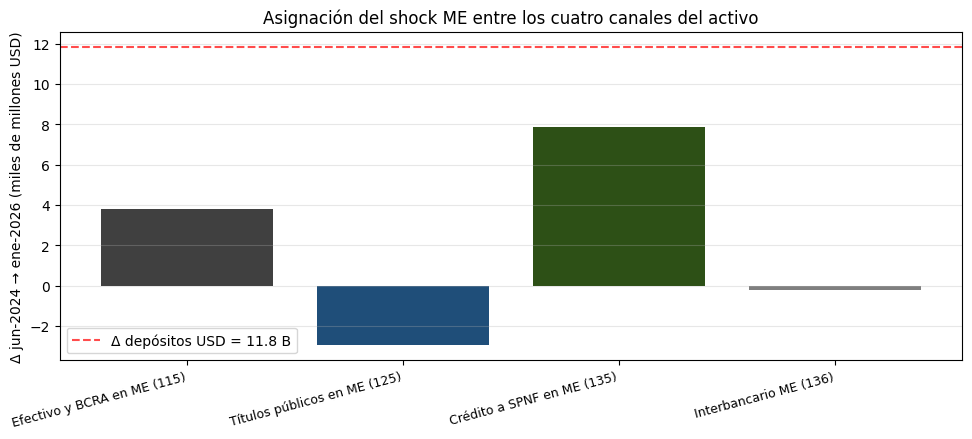

In [29]:
fig, ax = plt.subplots(figsize=(10, 4.5))
canales = ["Efectivo y BCRA en ME (115)", "Títulos públicos en ME (125)",
           "Crédito a SPNF en ME (135)", "Interbancario ME (136)"]
valores = [sistema.loc[c, "delta_usd_b"] for c in canales]
colors = ["#404040", "#1f4e79", "#2d5016", "#7f7f7f"]
ax.bar(canales, valores, color=colors)
ax.axhline(delta_depositos, color="red", ls="--", alpha=0.7, label=f"Δ depósitos USD = {delta_depositos:,.1f} B")
ax.set_ylabel("Δ jun-2024 → ene-2026 (miles de millones USD)")
ax.set_title("Asignación del shock ME entre los cuatro canales del activo")
ax.set_xticklabels(canales, rotation=15, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Asignación al activo ME — ambas ventanas, lado a lado

Versión parametrizada de la tabla anterior, calculada en las dos ventanas definidas al inicio del notebook (corta pre-cepo y larga terminal). Alimenta §4.4 y §4.5 de [`docs/notas/sintesis_para_modelo.md`](../../docs/notas/sintesis_para_modelo.md).

Convención cambiaria: Δ activos y Δ pasivos se convierten al TC del mes terminal de cada ventana, evitando distorsión por re-valuación de stocks.

In [30]:
def saldos_por_canal_sistema(yyyymm: int) -> pd.Series:
    """Saldo agregado al sistema, por capítulo del activo ME y depósitos USD del SPNF, en pesos. Convención económica (abs)."""
    q = f"""
    select
      abs(sum(case when codigo_cuenta like '115%' then saldo else 0 end)) as cap_115,
      abs(sum(case when codigo_cuenta like '125%' then saldo else 0 end)) as cap_125,
      abs(sum(case when codigo_cuenta like '135%' then saldo else 0 end)) as cap_135,
      abs(sum(case when codigo_cuenta like '136%' then saldo else 0 end)) as cap_136,
      abs(sum(case when codigo_cuenta like '315%' or codigo_cuenta like '316%' then saldo else 0 end)) as dep_usd_spnf
    from panel_bancos
    where yyyymm = {yyyymm}
    """
    return duckdb.sql(q).df().iloc[0]

def delta_canales_usd(t0: int, t1: int) -> pd.DataFrame:
    s0, s1 = saldos_por_canal_sistema(t0), saldos_por_canal_sistema(t1)
    delta_pesos = s1 - s0
    delta_usd = delta_pesos / tc[t1] / 1e9
    df = pd.DataFrame({"delta_usd_b": delta_usd})
    df["pct_delta_dep_usd"] = df["delta_usd_b"] / df.loc["dep_usd_spnf", "delta_usd_b"] * 100
    return df

tablas_canales = {nombre: delta_canales_usd(t0, t1) for nombre, (t0, t1) in VENTANAS.items()}

comparacion_canales = pd.concat(
    {nombre: t.rename(columns={"delta_usd_b": "Δ USD B", "pct_delta_dep_usd": "% Δ dep USD"})
     for nombre, t in tablas_canales.items()},
    axis=1
)
comparacion_canales

corta (jun-24 -> mar-25, pre-cepo)              \
                                        Δ USD B % Δ dep USD   
cap_115                                    5.70       38.36   
cap_125                                   -1.91      -12.83   
cap_135                                    8.85       59.59   
cap_136                                   -0.16       -1.08   
dep_usd_spnf                              14.85      100.00   

             larga (jun-24 -> ene-26, post-cepo)              
                                         Δ USD B % Δ dep USD  
cap_115                                    13.72       47.80  
cap_125                                    -0.51       -1.78  
cap_135                                    15.96       55.59  
cap_136                                    -0.16       -0.54  
dep_usd_spnf                               28.71      100.00

In [31]:
# Cobertura: ¿cuánto del Δ depósitos USD explican los 4 canales del activo ME?
for nombre, t in tablas_canales.items():
    suma_4 = t.loc[["cap_115","cap_125","cap_135","cap_136"], "delta_usd_b"].sum()
    delta_dep = t.loc["dep_usd_spnf", "delta_usd_b"]
    print(f"{nombre:55s}  Δ dep USD={delta_dep:+6.2f}B  Σ Δ canales={suma_4:+6.2f}B  cobertura={suma_4/delta_dep*100:5.1f}%")

corta (jun-24 -> mar-25, pre-cepo)                       Δ dep USD=+14.85B  Σ Δ canales=+12.48B  cobertura= 84.0%
larga (jun-24 -> ene-26, post-cepo)                      Δ dep USD=+28.71B  Σ Δ canales=+29.02B  cobertura=101.1%


### Descomposición mecánica vs discrecional del encaje

El TO Efectivo Mínimo (Com. A 8397, sec. 1.3.2.2 + sec. 7.5) impone encaje **25% sobre depósitos a la vista en ME**, incluyendo CERA. El Δ del cap. 115 (cuenta corriente BCRA en ME) tiene entonces un componente mecánico (25% × Δ depósitos vista ME) y un residuo discrecional (encaje voluntario sobre la posición spot, o atribuible a otros depósitos no-vista que también crecieron).

Identificamos cuentas vista vs plazo dentro de caps 315+316 por sufijo de subcuenta. Refinamiento futuro: cruzar contra `dim_cuentas` con un crosswalk explícito vista/plazo en lugar de patrón.

In [32]:
# Sufijos de subcuenta dentro de caps 315/316 que corresponden a cuentas a la vista (encaje 25%)
VISTA_SUFIJOS = (
    "706","707","708","712","716","718","723","724","725",  # SPNF residentes país (cap 315/316 sub 7xx)
    "106","107","108","112","116","118","123","124","113",  # SPub no fin / residentes exterior sub 1xx
    "793","794","183","147",                                  # CERA (las cuatro)
    "791","792",                                              # cuentas especiales agro / exportadores
)

def saldo_dep_vista_me(yyyymm: int) -> float:
    cond = " or ".join([f"right(codigo_cuenta,3)='{s}'" for s in VISTA_SUFIJOS])
    q = f"""
    select abs(sum(saldo)) as s
    from panel_bancos
    where yyyymm = {yyyymm}
      and (codigo_cuenta like '315%' or codigo_cuenta like '316%')
      and ({cond})
    """
    return duckdb.sql(q).df().iloc[0]["s"]

filas = []
for nombre, (t0, t1) in VENTANAS.items():
    delta_vista_pesos = saldo_dep_vista_me(t1) - saldo_dep_vista_me(t0)
    delta_vista_usd = delta_vista_pesos / tc[t1] / 1e9
    encaje_mecanico = 0.25 * delta_vista_usd
    delta_cap115_usd = tablas_canales[nombre].loc["cap_115", "delta_usd_b"]
    residuo = delta_cap115_usd - encaje_mecanico
    filas.append({
        "ventana": nombre,
        "Δ dep vista ME (USD B)": delta_vista_usd,
        "Encaje mecánico (25% × Δ vista)": encaje_mecanico,
        "Δ cap 115 observado (USD B)": delta_cap115_usd,
        "Residuo discrecional": residuo,
        "% mecánico del Δ cap 115": encaje_mecanico/delta_cap115_usd*100 if delta_cap115_usd != 0 else float('nan'),
    })
pd.DataFrame(filas).set_index("ventana")

,Δ dep vista ME (USD B),Encaje mecánico (25% × Δ vista),Δ cap 115 observado (USD B),Residuo discrecional,% mecánico del Δ cap 115
ventana,,,,,
"corta (jun-24 -> mar-25, pre-cepo)",13.14,3.29,5.70,2.41,57.68
"larga (jun-24 -> ene-26, post-cepo)",20.09,5.02,13.72,8.70,36.59


# Anticipación: dinámica sistémica pre/post-shock

Antes de meternos en heterogeneidad por banco y en la construcción del γ̂_b del Paso 1, hay que validar que el shock CERA no está anticipado por las variables outcome. La pregunta concreta: entre el balotaje Milei (nov-2023) y la Com. A 8062 (jul-2024) hubo siete meses de "anuncio gradual" en los que el blanqueo se discutió en campaña, se envió al Congreso (Ley Bases) y se sancionó. ¿Las variables del balance bancario empezaron a moverse en alguno de esos hitos, o el quiebre es nítido recién en jul-ago 2024?

Si las series están planas pre-jul-2024 y saltan en jul-2024 → no hay anticipación, t=0 = jul-2024 es la fecha correcta del event study.  
Si hay drift previo desde algún hito anterior → hay anticipación al anuncio (no a la implementación), y t=0 debe correrse a esa fecha.

Cuatro hitos a marcar como verticales en cada gráfico:

| Fecha | Evento | Mecanismo si fuera el shock |
|---|---|---|
| 19-nov-2023 | Milei electo (balotaje) | Expectativa política |
| 22-abr-2024 | Proyecto Ley Bases / paquete fiscal al Congreso | Anuncio de la regla |
| 27-jun-2024 | Sanción Ley 27.743 | Norma vigente |
| 15-jul-2024 | Com. A 8062 BCRA + alta cuentas CERA | Operatoria real |

Variables del set mínimo (ver Chodorow-Reich 2014, Paravisini et al. 2015, Jiménez et al. 2017):
- **Pasivo**: depósitos USD del SPNF (caps 315+316). Variable de tratamiento.
- **Activo ME**: encaje (cap 115), Tesoro USD + Letras BCRA ME (cap 125), crédito ME total (cap 135), interbancario ME (cap 136).
- **Sub-aperturas cap 135**: prefinanciación de exportaciones (135199/499/799), documentos a sola firma (135115), documentos comprados (135121), hipotecarios (135108), resto.
- **Cross-currency**: crédito en pesos al SPNF (cap 131), para test del canal de sustitución de balance.

In [33]:
# Series sistémicas mensuales con unidad explícita por variable
VENTANA_GRAFICO = (202201, 202601)

def serie_sistemica(patterns_or_codes, label, unidad="usd"):
    """Serie mensual del agregado al sistema en la unidad indicada.
    
    unidad: "usd" -> USD nominal (al A-3500 de cada mes). Default para variables ME.
            "ars_real" -> pesos constantes de jul-2024, deflactado por IPC Nacional. Default para ARS.
    """
    if any('%' in p for p in patterns_or_codes):
        cond = " or ".join([f"codigo_cuenta like '{p}'" for p in patterns_or_codes])
    else:
        cond = "codigo_cuenta in (" + ",".join([f"'{c}'" for c in patterns_or_codes]) + ")"
    q = f"""
    select yyyymm, abs(sum(saldo)) as saldo_ars
    from panel_bancos
    where ({cond}) and yyyymm between {VENTANA_GRAFICO[0]} and {VENTANA_GRAFICO[1]}
    group by yyyymm order by yyyymm
    """
    d = duckdb.sql(q).df()
    if unidad == "usd":
        d = d.merge(fx_eom, on='yyyymm', how='left')
        d['valor'] = d['saldo_ars'] / d['tc_a3500'] / 1e9
        d['unidad'] = 'USD B'
    elif unidad == "ars_real":
        d['ipc'] = d['yyyymm'].map(ipc)
        d['valor'] = d['saldo_ars'] / d['ipc'] * IPC_BASE / 1e12
        d['unidad'] = f'ARS B constantes {IPC_BASE_YYYYMM}'
    else:
        raise ValueError(f"unidad debe ser 'usd' o 'ars_real', no {unidad}")
    d['fecha'] = pd.to_datetime(d.yyyymm.astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    d['categoria'] = label
    return d[['fecha','yyyymm','categoria','valor','unidad']]

# Categorías: cada una con su unidad apropiada según la moneda
CATEGORIAS = [
    # (label, patterns, unidad)
    ("Depósitos USD SPNF (315+316)",        ["315%", "316%"],            "usd"),
    ("Encaje ME (cap 115)",                 ["115%"],                    "usd"),
    ("Tesoro USD + Letras BCRA ME (cap 125)", ["125%"],                  "usd"),
    ("Crédito ME al SPNF (cap 135)",        ["135%"],                    "usd"),
    ("Interbancario ME (cap 136)",          ["136%"],                    "usd"),
    ("Prefinanciación export (135199/499/799)", ["135199","135499","135799"], "usd"),
    ("Doc. sola firma (135115)",            ["135115"],                  "usd"),
    ("Doc. comprados (135121)",             ["135121"],                  "usd"),
    ("Crédito ARS al SPNF (cap 131)",       ["131%"],                    "ars_real"),
    ("Depósitos ARS SPNF (cap 311 ex-CERA-ARS)", ["311%"],               "ars_real"),
]

series_dict = {label: serie_sistemica(pats, label, u) for label, pats, u in CATEGORIAS}

# Cap 135 "resto" = total - subaperturas identificadas (en USD)
total_135 = series_dict["Crédito ME al SPNF (cap 135)"].set_index('yyyymm')['valor']
sub_keys = ["Prefinanciación export (135199/499/799)", "Doc. sola firma (135115)", "Doc. comprados (135121)"]
sub_135_sum = pd.Series(0.0, index=total_135.index)
for k in sub_keys:
    s = series_dict[k].set_index('yyyymm')['valor']
    sub_135_sum = sub_135_sum.add(s, fill_value=0)
resto_135 = pd.DataFrame({'yyyymm': total_135.index, 'valor': total_135 - sub_135_sum}).reset_index(drop=True)
resto_135['fecha'] = pd.to_datetime(resto_135.yyyymm.astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
resto_135['categoria'] = 'Resto cap 135 (otros préstamos ME)'
resto_135['unidad'] = 'USD B'
series_dict['Resto cap 135 (otros préstamos ME)'] = resto_135

# Hitos a marcar
HITOS = [
    ('2023-11-19', 'Milei electo',           '#888888', '-'),
    ('2024-04-22', 'Ley Bases al Congreso',  '#996600', '-.'),
    ('2024-06-27', 'Sanción Ley 27.743',     '#663399', '--'),
    ('2024-07-15', 'Com. A 8062 (CERA op.)', '#cc0000', '-'),
]

print(f"Series construidas: {len(series_dict)} categorías")
for label, v in series_dict.items():
    if v.empty:
        print(f"  ⚠️  {label}: sin datos en la ventana")
    else:
        print(f"  ✓ {label}: {len(v)} meses, unidad={v.iloc[0]['unidad']}, valor a jul-2024 = {v.loc[v.yyyymm==202407,'valor'].iloc[0] if (v.yyyymm==202407).any() else float('nan'):.2f}")


Series construidas: 11 categorías
  ✓ Depósitos USD SPNF (315+316): 49 meses, unidad=USD B, valor a jul-2024 = 21.10
  ✓ Encaje ME (cap 115): 49 meses, unidad=USD B, valor a jul-2024 = 13.44
  ✓ Tesoro USD + Letras BCRA ME (cap 125): 49 meses, unidad=USD B, valor a jul-2024 = 6.47
  ✓ Crédito ME al SPNF (cap 135): 49 meses, unidad=USD B, valor a jul-2024 = 6.67
  ✓ Interbancario ME (cap 136): 49 meses, unidad=USD B, valor a jul-2024 = 0.32
  ✓ Prefinanciación export (135199/499/799): 49 meses, unidad=USD B, valor a jul-2024 = 2.78
  ✓ Doc. sola firma (135115): 22 meses, unidad=USD B, valor a jul-2024 = nan
  ✓ Doc. comprados (135121): 7 meses, unidad=USD B, valor a jul-2024 = nan
  ✓ Crédito ARS al SPNF (cap 131): 49 meses, unidad=ARS B constantes 202407, valor a jul-2024 = 39.06
  ✓ Depósitos ARS SPNF (cap 311 ex-CERA-ARS): 49 meses, unidad=ARS B constantes 202407, valor a jul-2024 = 77.68
  ✓ Resto cap 135 (otros préstamos ME): 49 meses, unidad=USD B, valor a jul-2024 = 3.89


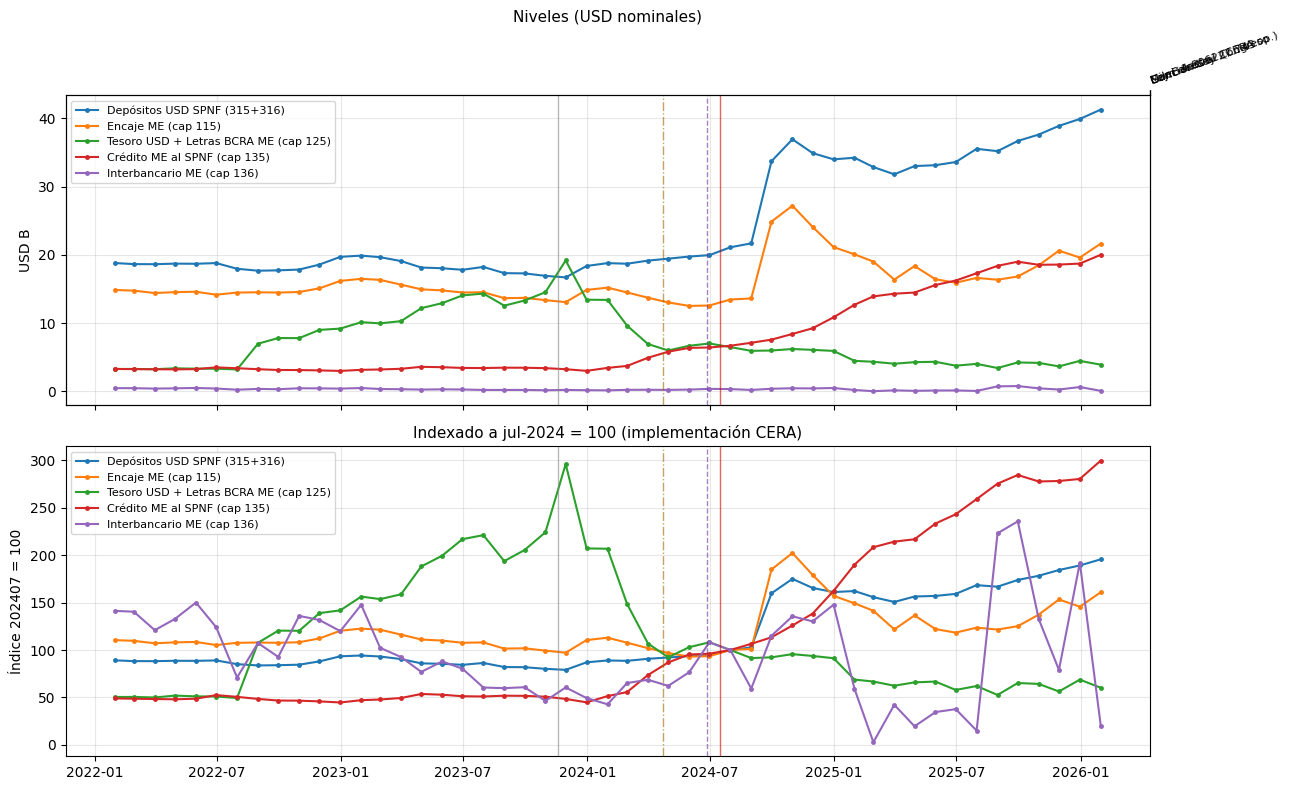

In [34]:
# Figura 1 — Panorama agregado: pasivo USD vs los cuatro canales del activo ME (todos en USD nominales)
def plot_series(ax, etiquetas, titulo, normalizar=False, base_yyyymm=202407):
    for label in etiquetas:
        d = series_dict[label].sort_values('yyyymm')
        if d.empty or d['valor'].sum() == 0:
            continue
        if normalizar:
            base_rows = d.loc[d.yyyymm == base_yyyymm, 'valor']
            if base_rows.empty or base_rows.iloc[0] == 0 or pd.isna(base_rows.iloc[0]):
                continue
            y = d['valor'] / base_rows.iloc[0] * 100
        else:
            y = d['valor']
        ax.plot(d['fecha'], y, marker='o', ms=2.5, lw=1.5, label=label)
    for fecha, etiqueta, color, ls in HITOS:
        ax.axvline(pd.Timestamp(fecha), color=color, ls=ls, alpha=0.6, lw=1)
    ax.set_title(titulo, fontsize=11)
    if normalizar:
        ax.set_ylabel(f"Índice {base_yyyymm} = 100")
    else:
        # Las series ME van en USD, las ARS en pesos reales — para ESTE plot solo entran ME
        unidades = set(series_dict[l].iloc[0]['unidad'] for l in etiquetas if not series_dict[l].empty)
        ax.set_ylabel(" / ".join(unidades))
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
panorama = ["Depósitos USD SPNF (315+316)",
            "Encaje ME (cap 115)",
            "Tesoro USD + Letras BCRA ME (cap 125)",
            "Crédito ME al SPNF (cap 135)",
            "Interbancario ME (cap 136)"]
plot_series(axes[0], panorama, "Niveles (USD nominales)")
plot_series(axes[1], panorama, "Indexado a jul-2024 = 100 (implementación CERA)", normalizar=True)
ax_top = axes[0].twiny()
ax_top.set_xlim(axes[0].get_xlim())
ax_top.set_xticks([pd.Timestamp(f).toordinal() for f, _, _, _ in HITOS])
ax_top.set_xticklabels([e for _, e, _, _ in HITOS], fontsize=8, rotation=20, ha='left')
plt.tight_layout()
plt.show()


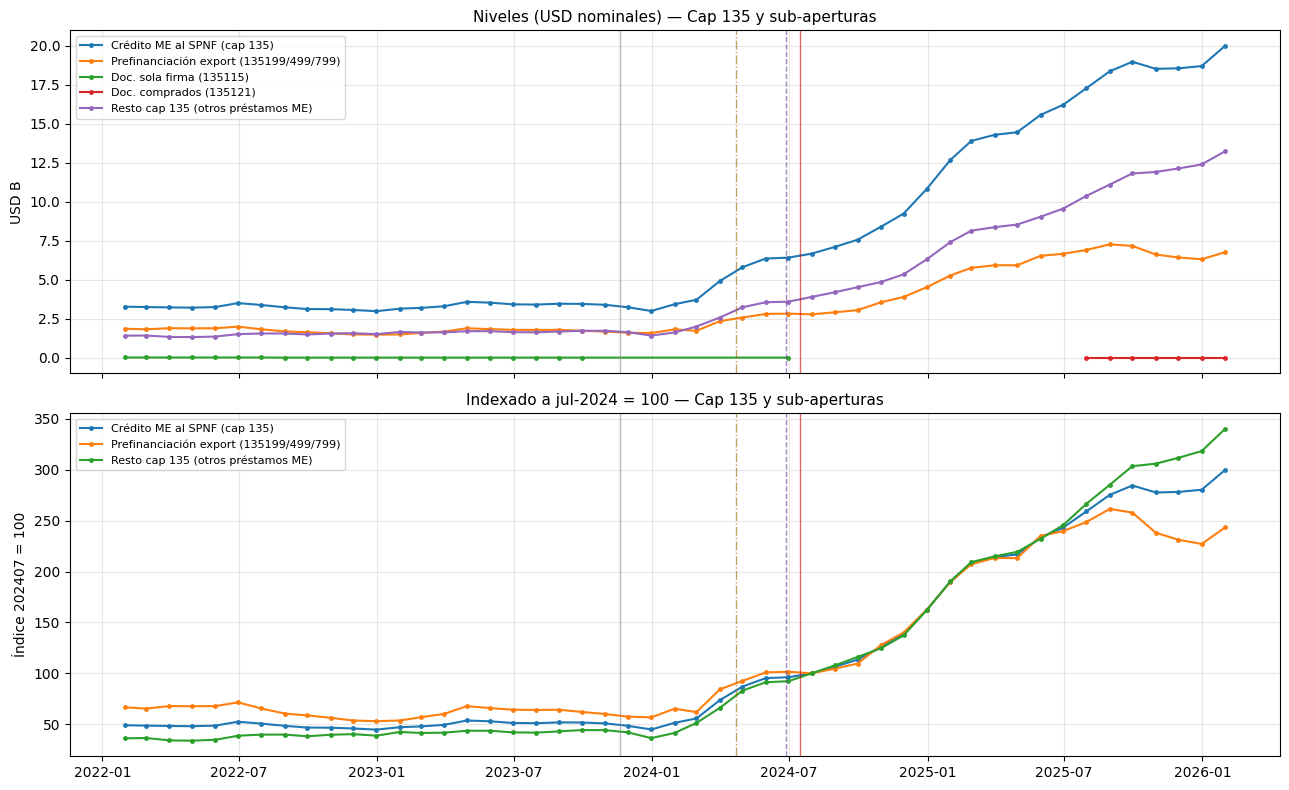

In [35]:
# Figura 2 — Cap 135 desglosado (todo en USD nominales): ¿qué subcategoría se mueve cuándo?
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
cap135 = ["Crédito ME al SPNF (cap 135)",
          "Prefinanciación export (135199/499/799)",
          "Doc. sola firma (135115)",
          "Doc. comprados (135121)",
          "Resto cap 135 (otros préstamos ME)"]
plot_series(axes[0], cap135, "Niveles (USD nominales) — Cap 135 y sub-aperturas")
plot_series(axes[1], cap135, "Indexado a jul-2024 = 100 — Cap 135 y sub-aperturas", normalizar=True)
plt.tight_layout()
plt.show()


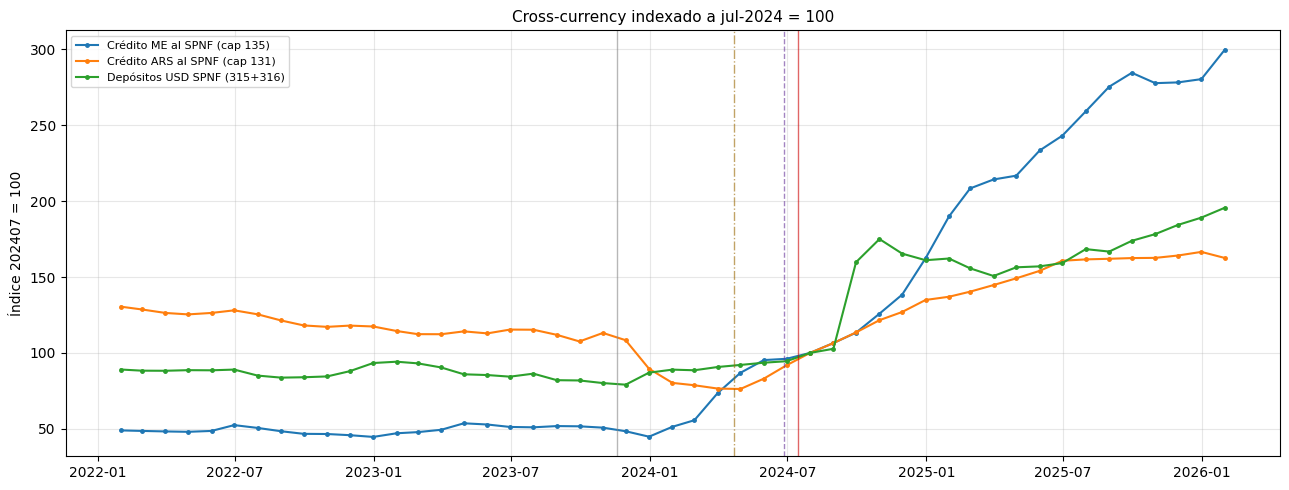

In [36]:
# Figura 3 — Cross-currency: crédito ME (USD) vs crédito ARS (pesos constantes jul-2024)
# Como están en unidades distintas, mostramos sólo la versión indexada a jul-2024 = 100
fig, ax = plt.subplots(figsize=(13, 5))
cross = ["Crédito ME al SPNF (cap 135)", "Crédito ARS al SPNF (cap 131)", "Depósitos USD SPNF (315+316)"]
plot_series(ax, cross, "Cross-currency indexado a jul-2024 = 100", normalizar=True)
plt.tight_layout()
plt.show()


In [37]:
# Tabla resumen: niveles en cada fecha hito (en la unidad nativa de la variable)
fechas_referencia = {
    202311: "nov-2023 (Milei electo)",
    202401: "ene-2024",
    202404: "abr-2024 (Ley Bases)",
    202406: "jun-2024 (Sanción)",
    202407: "jul-2024 (Com A 8062, base)",
    202410: "oct-2024 (peak CERA)",
    202503: "mar-2025 (pre-cepo)",
    202601: "ene-2026 (terminal)",
}
filas = []
for label in ["Depósitos USD SPNF (315+316)",
              "Encaje ME (cap 115)",
              "Tesoro USD + Letras BCRA ME (cap 125)",
              "Crédito ME al SPNF (cap 135)",
              "Prefinanciación export (135199/499/799)",
              "Crédito ARS al SPNF (cap 131)",
              "Depósitos ARS SPNF (cap 311 ex-CERA-ARS)"]:
    d = series_dict[label].set_index('yyyymm')['valor']
    unidad_label = series_dict[label].iloc[0]['unidad']
    fila = {"variable": f"{label} [{unidad_label}]"}
    for ym, nombre in fechas_referencia.items():
        v = d.get(ym, float('nan'))
        fila[nombre] = v
    filas.append(fila)
tabla_niveles = pd.DataFrame(filas).set_index("variable").round(2)
print("Niveles en cada fecha hito (unidades nativas; ME en USD nominales, ARS en pesos constantes jul-2024):")
tabla_niveles


Niveles en cada fecha hito (unidades nativas; ME en USD nominales, ARS en pesos constantes jul-2024):


,nov-2023 (Milei electo),ene-2024,abr-2024 (Ley Bases),jun-2024 (Sanción),"jul-2024 (Com A 8062, base)",oct-2024 (peak CERA),mar-2025 (pre-cepo),ene-2026 (terminal)
variable,,,,,,,,
Depósitos USD SPNF (315+316) [USD B],16.69,18.78,19.43,19.95,21.10,36.92,31.79,41.27
Encaje ME (cap 115) [USD B],13.06,15.18,13.02,12.56,13.44,27.19,16.37,21.64
Tesoro USD + Letras BCRA ME (cap 125) [USD B],19.17,13.39,5.98,7.00,6.47,6.19,4.04,3.90
Crédito ME al SPNF (cap 135) [USD B],3.23,3.43,5.80,6.42,6.67,8.40,14.30,20.00
Prefinanciación export (135199/499/799) [USD B],1.60,1.81,2.57,2.82,2.78,3.55,5.93,6.76
Crédito ARS al SPNF (cap 131) [ARS B constantes 202407],42.34,31.35,29.78,35.88,39.06,47.49,56.52,63.49
Depósitos ARS SPNF (cap 311 ex-CERA-ARS) [ARS B constantes 202407],87.33,82.39,75.19,79.44,77.68,82.31,85.26,85.34


## Heterogeneidad por banco

La pregunta más sutil: ¿todos los bancos asignaron parecido, o hubo diferencias sistemáticas según el modelo de negocio? Para cada banco con CERA > 0, computo la variación en cada uno de los cuatro canales y grafico contra el shock CERA recibido.

In [38]:
# Δ por banco por canal
wide = por_banco_canal.pivot(index="codigo_entidad", columns="yyyymm", values=["c115","c125","c135","c136"])
wide.columns = [f"{var}_{y}" for var, y in wide.columns]
wide = wide.fillna(0)
for c in ["c115","c125","c135","c136"]:
    wide[f"delta_{c}"] = wide[f"{c}_{T1_CORTO}"] - wide[f"{c}_{T0}"]

# Merge con CERA share
delta_por_banco = wide.reset_index().merge(
    shares[["codigo_entidad", "sigla", "saldo", "share"]].rename(columns={"share": "share_cera"}),
    on="codigo_entidad", how="inner"
)
delta_por_banco["cera_peak_usd_b"] = delta_por_banco["saldo"] / fx_eom.loc[fx_eom.yyyymm == mes_peak_sistema, "tc_a3500"].iloc[0] / 1e9
delta_por_banco = delta_por_banco.sort_values("share_cera", ascending=False)
delta_por_banco[["codigo_entidad", "sigla", "cera_peak_usd_b",
                 "delta_c115", "delta_c125", "delta_c135", "delta_c136"]].head(15).round(2)

,codigo_entidad,sigla,cera_peak_usd_b,delta_c115,delta_c125,delta_c135,delta_c136
0,00007,GALICIA,2.98,1.35,-0.41,1.94,-0.06
12,00072,SANTAND,2.74,1.12,-0.02,0.82,-0.15
4,00017,BBVA.AR,1.47,0.06,-0.24,1.10,-0.01
25,00285,MACRO,1.39,0.30,-0.01,0.73,0.00
1,00011,NACION,0.87,-0.47,-1.32,1.29,0.00
2,00014,PRBSAS,0.46,-0.12,-0.07,0.47,0.00
3,00015,INDUSTR,0.42,0.25,-0.05,0.52,0.00
19,00191,CREDICO,0.41,0.27,-0.34,0.05,0.00
6,00027,SUPERVI,0.29,0.29,0.07,0.16,0.00
18,00150,HSBC,0.28,0.27,-0.03,-0.02,0.00


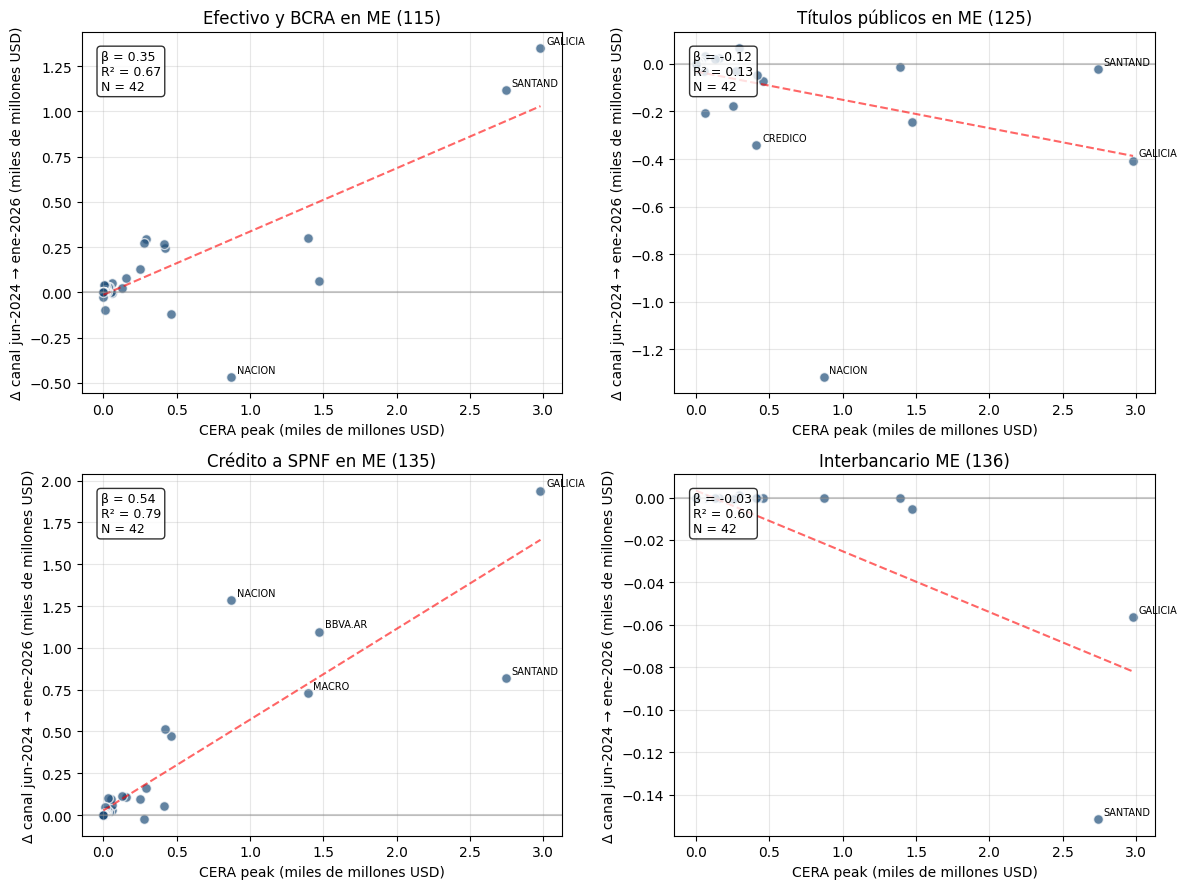

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
canales_cols = [("delta_c115", "Efectivo y BCRA en ME (115)"),
                ("delta_c125", "Títulos públicos en ME (125)"),
                ("delta_c135", "Crédito a SPNF en ME (135)"),
                ("delta_c136", "Interbancario ME (136)")]

from scipy.stats import linregress
for ax, (col, titulo) in zip(axes.flatten(), canales_cols):
    d = delta_por_banco[delta_por_banco.cera_peak_usd_b > 0]
    x = d.cera_peak_usd_b
    y = d[col]
    ax.scatter(x, y, s=50, alpha=0.7, color="#1f4e79", edgecolor="white")
    if len(d) > 2:
        res = linregress(x, y)
        xr = np.linspace(0, x.max(), 50)
        ax.plot(xr, res.slope * xr + res.intercept, ls="--", color="red", alpha=0.6)
        ax.text(0.04, 0.95, f"β = {res.slope:.2f}\nR² = {res.rvalue**2:.2f}\nN = {len(d)}",
                transform=ax.transAxes, fontsize=9, va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    # Etiquetar outliers
    for _, row in d.iterrows():
        if abs(row[col]) > d[col].std() * 1.5 or row.cera_peak_usd_b > 2:
            ax.annotate(str(row.sigla)[:8] if pd.notna(row.sigla) else row.codigo_entidad,
                        (row.cera_peak_usd_b, row[col]), fontsize=7,
                        xytext=(4, 3), textcoords="offset points")

    ax.set_xlabel("CERA peak (miles de millones USD)")
    ax.set_ylabel("Δ canal jun-2024 → ene-2026 (miles de millones USD)")
    ax.set_title(titulo)
    ax.grid(alpha=0.3)
    ax.axhline(0, color="gray", alpha=0.4)

plt.tight_layout()
plt.show()

**Interpretación del coeficiente β**: por cada USD 1B adicional de CERA recibida, el banco aumentó en β miles de millones de USD el saldo del canal. La suma de los cuatro β debería aproximar la unidad si los cuatro canales absorben completamente el shock (balance sheet identity); desvíos vienen de otros pasivos ME compensadores, crecimiento de activos no considerados, y reclasificaciones.

**Lectura regulatoria del +43% a encaje BCRA en ME**. Las CERA están sujetas a las exigencias estándar del régimen de Efectivo Mínimo del BCRA (TO Efectivo Mínimo, sec. 7.5 + 1.3.2.2): al considerarse depósitos a la vista en moneda extranjera, exigen una integración del **25% en cuenta corriente del BCRA** (cuenta 115015). Por lo tanto:

- De los USD 21.4 B de aumento en depósitos USD del SPNF, **USD 5.35 B (25%) son encaje obligatorio mecánico**.
- El residuo entre el encaje observado (+USD 9.21 B, 43% del shock) y el componente obligatorio (USD 5.35 B, 25%) es de **USD 3.86 B (≈18% del shock)**, atribuible a (i) encaje sobre otros depósitos ME que también crecieron en el período, (ii) decisión voluntaria del banco de mantener buffer de liquidez por encima de la exigencia mínima.

Esta descomposición es importante para distinguir el componente regulatorio mecánico del componente discrecional del banco. La parte voluntaria es testeable como respuesta consistente con la hipótesis Diamond-Dybvig (depósitos CERA percibidos como más volátiles → mayor buffer voluntario). Detalles regulatorios completos en `docs/notas/cera_regimen.md` §5.bis.

# Pre-trends formales

Test de exogeneidad del tratamiento: ¿los bancos que recibieron más CERA estaban creciendo más rápido en depósitos USD **antes** del shock? Si el coeficiente del grupo de exposición sobre el crecimiento pre-shock no es significativo, el shock CERA puede tratarse como exógeno respecto del momentum del balance.

Especificación: `crec_dep_USD_b (jun-2022 → jun-2024) = α + β · medida_exposicion_b + ε_b`, errores HC3.

In [40]:
import statsmodels.api as sm

PRE_INI = 202207  # serie_bancos arranca en 202207
PRE_FIN = T0  # jun-2024

dep_pre_ini = serie_bancos.query("yyyymm == @PRE_INI")[["codigo_entidad", "dep_usd"]].rename(columns={"dep_usd": "dep_ini"})
dep_pre_fin = serie_bancos.query("yyyymm == @PRE_FIN")[["codigo_entidad", "dep_usd"]].rename(columns={"dep_usd": "dep_fin"})

pre = dep_pre_ini.merge(dep_pre_fin, on="codigo_entidad", how="inner")
pre["crec_pre"] = (pre["dep_fin"] / pre["dep_ini"] - 1) * 100
pre = pre.merge(exposicion_alt[["codigo_entidad", "share_cera", "intensidad"]], on="codigo_entidad", how="inner")
pre = pre.replace([np.inf, -np.inf], np.nan).dropna(subset=["crec_pre"])

for var in ["share_cera", "intensidad"]:
    sub = pre.dropna(subset=[var])
    X = sm.add_constant(sub[var])
    y = sub["crec_pre"]
    res = sm.OLS(y, X).fit(cov_type="HC3")
    print(f"--- crec_dep_USD_pre ~ {var} (n={len(sub)}) ---")
    print(res.summary().tables[1])
    print()

--- crec_dep_USD_pre ~ share_cera (n=39) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.9706     25.717      1.360      0.174     -15.434      85.375
share_cera   -48.6802    204.530     -0.238      0.812    -449.551     352.191

--- crec_dep_USD_pre ~ intensidad (n=39) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         55.6732     39.443      1.411      0.158     -21.633     132.980
intensidad   -38.7181     36.737     -1.054      0.292    -110.722      33.286



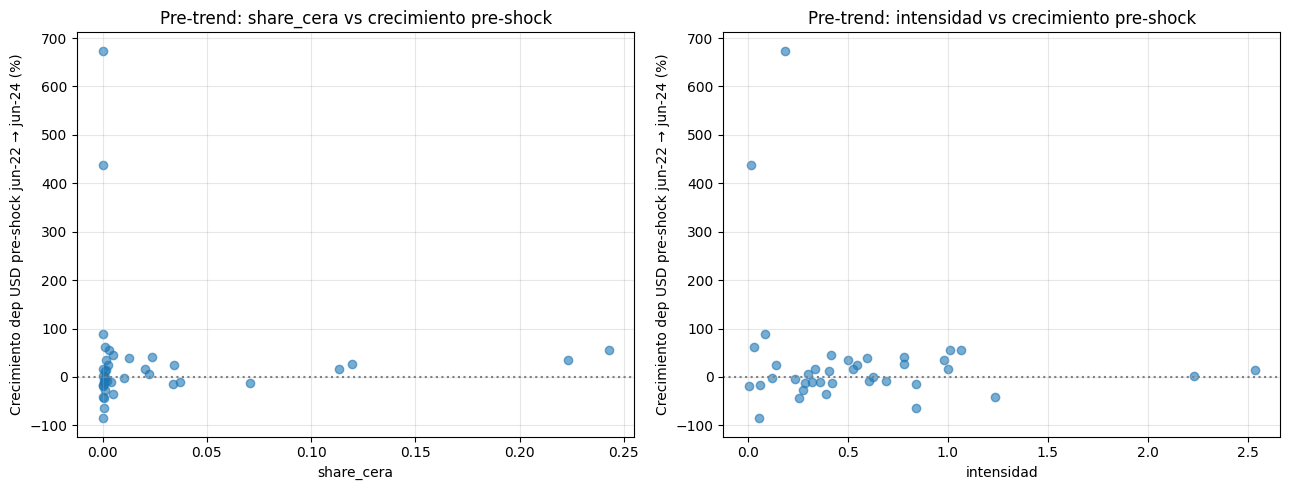

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, var in zip(axes, ["share_cera", "intensidad"]):
    ax.scatter(pre[var], pre["crec_pre"], alpha=0.6)
    ax.axhline(0, color="gray", ls=":")
    ax.set_xlabel(var)
    ax.set_ylabel("Crecimiento dep USD pre-shock jun-22 → jun-24 (%)")
    ax.set_title(f"Pre-trend: {var} vs crecimiento pre-shock")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Síntesis provisoria

Las observaciones que se desprenden de estas dos secciones, a revisitar cuando se agreguen los pasos siguientes:

- **Magnitud y timing**: (completar al ejecutar — confirmar que el peak cae en sep-oct 2024 con ≈USD 12B, consistente con el dato público de ≈USD 20B declarados y la tasa de permanencia en CERA).
- **Dominancia de la cuenta 315794**: la cuenta USD residentes país es la que absorbe la mayor parte del flujo; las otras tres son marginales.
- **Concentración**: (revisar HHI y share top-k; si el top-5 supera el 75%, la estrategia cross-sectional tiene poco margen).
- **Relación con tamaño preexistente**: si la correlación entre share pre-shock y share CERA es alta (>0.85), el shock es aproximadamente proporcional y la estrategia shift-share tiene sentido. Si es baja, hay que entender qué características del banco predicen la desviación.

**Próximos pasos** a agregar a este mismo notebook como nuevas secciones de nivel H1:

- Pre-tendencias de crecimiento de depósitos USD antes del blanqueo (sección 4).
- Asignación del flujo CERA dentro del balance: crédito vs Tesoro vs BCRA vs interbancario (sección 5).
- Restricciones regulatorias binding ex-ante: PGNME proxy y tope aplicaciones ME (sección 6).
- Construcción del instrumento shift-share a la Bartik (sección 7).